In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, kpss, grangercausalitytests
from statsmodels.tsa.vector_ar.vecm import coint_johansen
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from scipy.stats import skew, kurtosis, shapiro
import warnings
from datetime import datetime

# Ignore common warnings
warnings.filterwarnings('ignore')

# Set visualization styling
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')
plt.rcParams['figure.figsize'] = (14, 7) # Larger default figure size
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 12

In [2]:
# --- Step 1.1: Load & Verify Prep ---
# Load the dataset
file_path_filled = 'DC_Master_Data_Filled.csv'
df_filled = pd.read_csv(file_path_filled)

# Convert 'Date' column to datetime objects
df_filled['Date'] = pd.to_datetime(df_filled['Date'])

# Set 'Date' as the index
df_filled.set_index('Date', inplace=True)

# Sort the index (important for time series)
df_filled.sort_index(inplace=True)

# Verify the date range and index type
print("--- Data Loading and Verification ---")
print(f"Index type: {df_filled.index.dtype}")
print(f"Data starts from: {df_filled.index.min()}")
print(f"Data ends at: {df_filled.index.max()}") # Should be 2024-10-01
print(f"Is index monotonic increasing? {df_filled.index.is_monotonic_increasing}")

# Display the first few rows to confirm structure
print("\nFirst 5 rows:")
print(df_filled.head())

# Display the last few rows to confirm end date
print("\nLast 5 rows:")
print(df_filled.tail())

--- Data Loading and Verification ---
Index type: datetime64[ns]
Data starts from: 1990-01-01 00:00:00
Data ends at: 2024-10-01 00:00:00
Is index monotonic increasing? True

First 5 rows:
            House_Index    CPI  Poverty_Rate  Unemployment_Rate  \
Date                                                              
1990-01-01       102.11  132.0        13.500                3.8   
1990-04-01       102.41  133.9        13.675                3.8   
1990-07-01       101.87  135.7        13.850                4.7   
1990-10-01       100.53  138.2        14.025                4.9   
1991-01-01       101.07  139.1        14.200                5.3   

            Median_Household_Income   Population  Interest_Rate  \
Date                                                              
1990-01-01                  58390.0  4088.514122           8.23   
1990-04-01                  59160.0  4105.955000           8.26   
1990-07-01                  59930.0  4123.395878           8.15   
1990-10


--- Basic Information & Frequency ---
Shape of the DataFrame: (140, 9)
Time period covered: 1990-01-01 to 2024-10-01
Duration: 12692 days
Inferred frequency: QS-OCT (Quarterly Start)

--- Missing Value Check ---
No missing values found in df_filled.

--- Descriptive Statistics ---
                         count          mean           std           min  \
House_Index              140.0    205.550357     85.940726    100.000000   
CPI                      140.0    213.331111     50.484224    132.000000   
Poverty_Rate             140.0     12.980000      1.344243     10.500000   
Unemployment_Rate        140.0      5.711429      1.440278      2.600000   
Median_Household_Income  140.0  77782.821429  18003.414039  53450.000000   
Population               140.0   5363.002787    745.377352   4088.514122   
Interest_Rate            140.0      2.844429      2.381055      0.050000   
Mortgage_Rate            140.0      6.004671      1.880658      2.735000   
GDP                      140.0  1

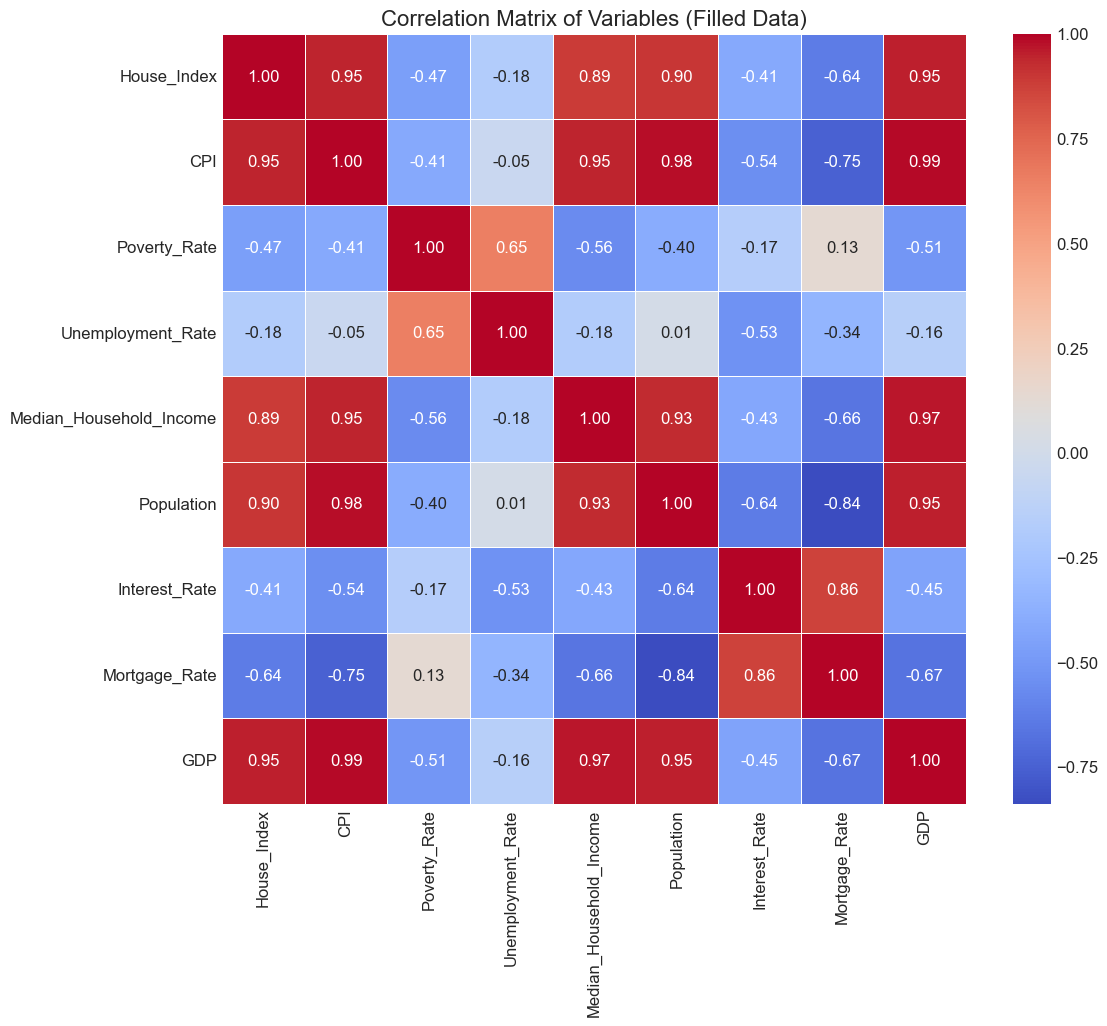


Correlation Matrix Values:
                         House_Index       CPI  Poverty_Rate  \
House_Index                 1.000000  0.946764     -0.469157   
CPI                         0.946764  1.000000     -0.412534   
Poverty_Rate               -0.469157 -0.412534      1.000000   
Unemployment_Rate          -0.184856 -0.054893      0.650927   
Median_Household_Income     0.891883  0.946841     -0.560498   
Population                  0.899567  0.979967     -0.397560   
Interest_Rate              -0.412040 -0.544887     -0.167833   
Mortgage_Rate              -0.635306 -0.745414      0.132130   
GDP                         0.951801  0.987087     -0.512303   

                         Unemployment_Rate  Median_Household_Income  \
House_Index                      -0.184856                 0.891883   
CPI                              -0.054893                 0.946841   
Poverty_Rate                      0.650927                -0.560498   
Unemployment_Rate                 1.000000     

In [4]:
# --- Step 1.2: Basic Information & Frequency ---
print("\n--- Basic Information & Frequency ---")
print(f"Shape of the DataFrame: {df_filled.shape}")
time_period = df_filled.index.max() - df_filled.index.min()
print(f"Time period covered: {df_filled.index.min().strftime('%Y-%m-%d')} to {df_filled.index.max().strftime('%Y-%m-%d')}")
print(f"Duration: {time_period.days} days")
# Infer frequency
inferred_freq = pd.infer_freq(df_filled.index)
if inferred_freq:
    print(f"Inferred frequency: {inferred_freq} (Quarterly Start)")
else:
    # Calculate diffs and check if mostly quarterly
    diffs = df_filled.index.to_series().diff().dt.days
    if diffs[1:].isin([89, 90, 91, 92]).all(): # Allowing for leap year variations
         print("Frequency: Confirmed Quarterly (QS - Quarter Start)")
    else:
         print("Frequency: Could not confirm consistent quarterly frequency.")

# --- Step 1.3: Verify Missing Values ---
print("\n--- Missing Value Check ---")
missing_values = df_filled.isnull().sum().sum()
if missing_values == 0:
    print("No missing values found in df_filled.")
else:
    print(f"Warning: Found {missing_values} missing values.")
    print(df_filled.isnull().sum())

# --- Step 1.4: Descriptive Statistics ---
print("\n--- Descriptive Statistics ---")
desc_stats = df_filled.describe().T
# Calculate IQR
desc_stats['IQR'] = desc_stats['75%'] - desc_stats['25%']
# Calculate Coefficient of Variation (CV) = std / mean
desc_stats['CV'] = (desc_stats['std'] / desc_stats['mean']).abs()
# Calculate Skewness and Kurtosis
desc_stats['Skewness'] = df_filled.apply(skew)
desc_stats['Kurtosis'] = df_filled.apply(kurtosis) # Fisher’s definition (normal=0)
print(desc_stats[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max', 'IQR', 'CV', 'Skewness', 'Kurtosis']])

# --- Step 1.5: Outlier Detection (IQR Method) ---
print("\n--- Outlier Detection (IQR Method) ---")
outliers_summary = {}
for column in df_filled.columns:
    Q1 = df_filled[column].quantile(0.25)
    Q3 = df_filled[column].quantile(0.75)
    IQR_val = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR_val
    upper_bound = Q3 + 1.5 * IQR_val

    # Identify outliers
    outliers = df_filled[(df_filled[column] < lower_bound) | (df_filled[column] > upper_bound)]
    if not outliers.empty:
        outliers_summary[column] = {
            'count': len(outliers),
            'indices': outliers.index.strftime('%Y-%m-%d').tolist(),
            'lower_bound': lower_bound,
            'upper_bound': upper_bound
        }
        print(f"Potential outliers found in '{column}': {len(outliers)}")
        # print(f"  Indices: {outliers.index.strftime('%Y-%m-%d').tolist()}")
        # print(f"  Bounds: [{lower_bound:.2f}, {upper_bound:.2f}]")
    else:
        print(f"No potential outliers found in '{column}' based on IQR.")
        outliers_summary[column] = {'count': 0}

# --- Step 1.6: Initial Correlation (Filled, Pre-Transformation) ---
print("\n--- Initial Correlation Matrix ---")
correlation_matrix = df_filled.corr()

# Plotting the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Variables (Filled Data)')
plt.show()

print("\nCorrelation Matrix Values:")
print(correlation_matrix)


--- Time Series Plots for All Variables (with Recessions) ---


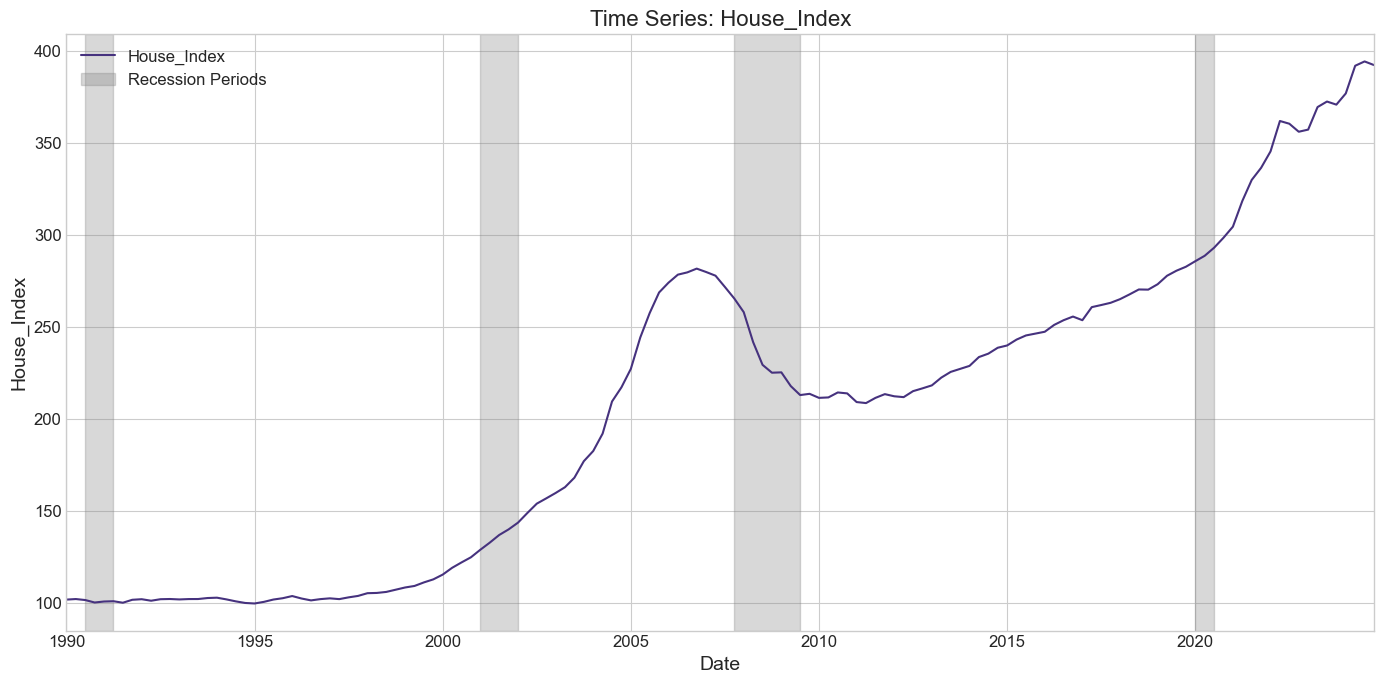

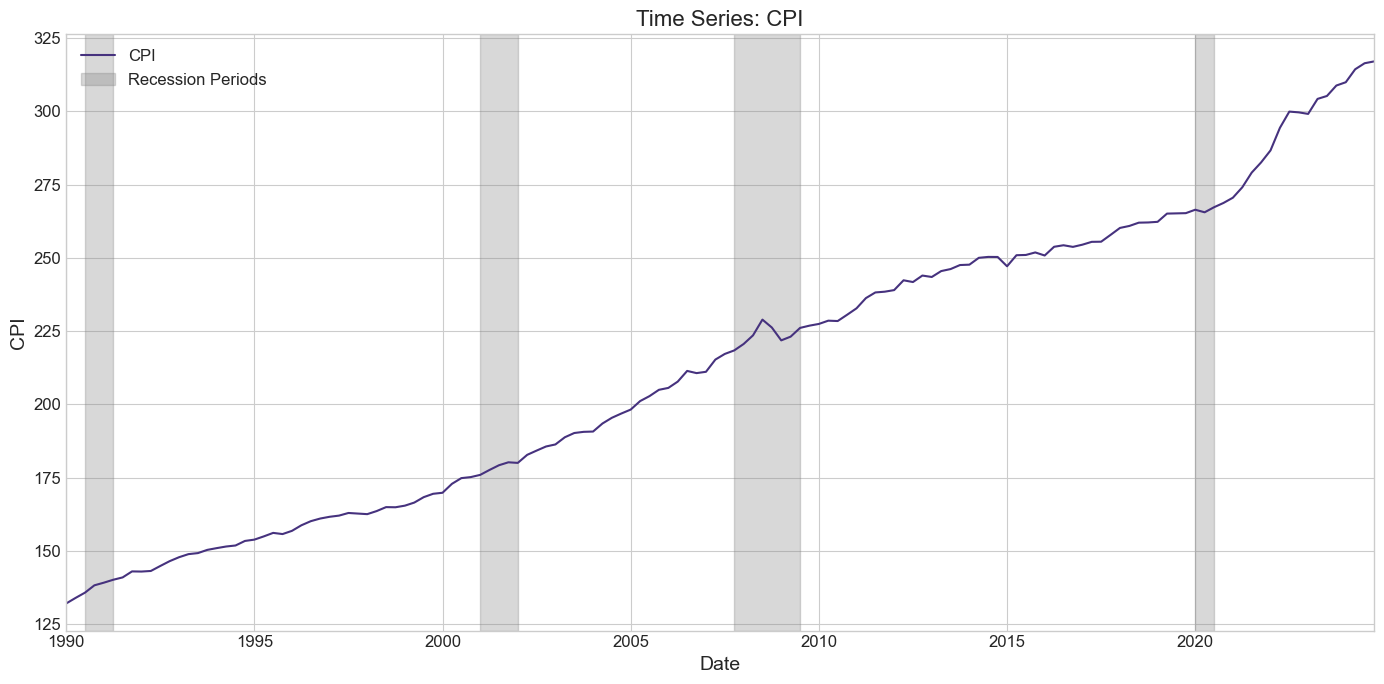

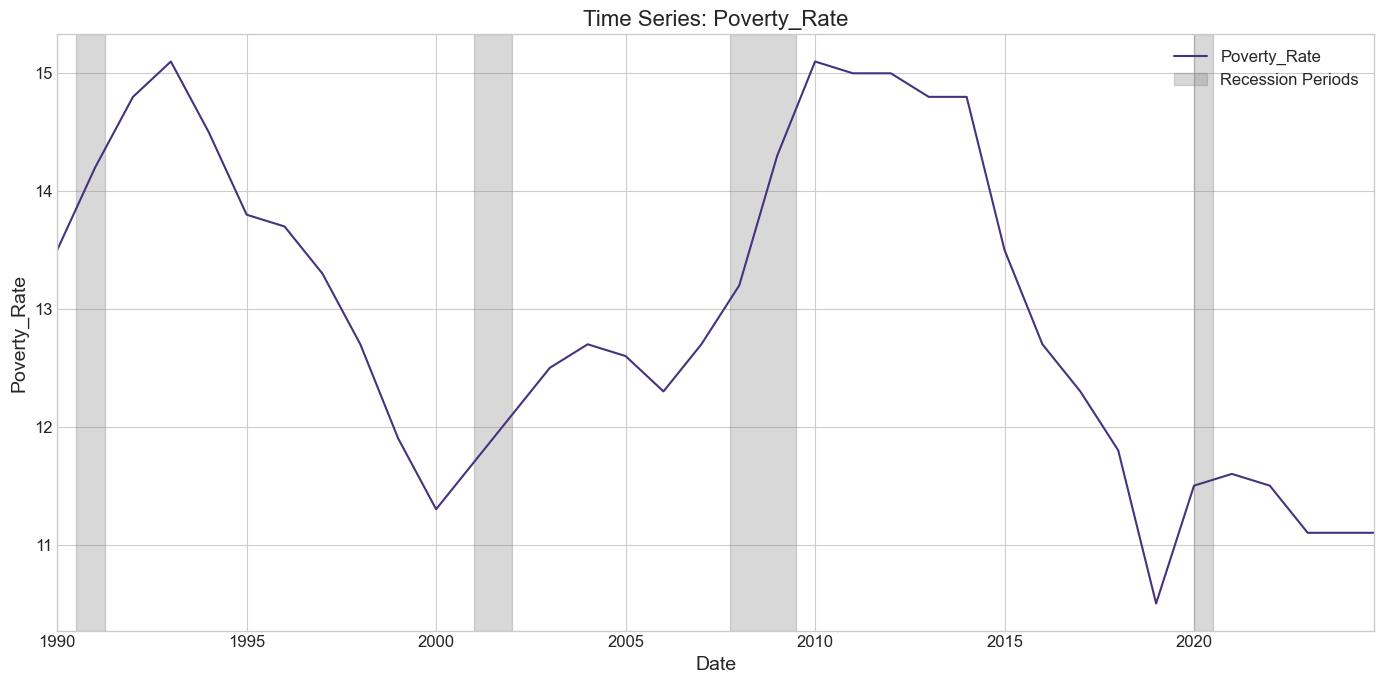

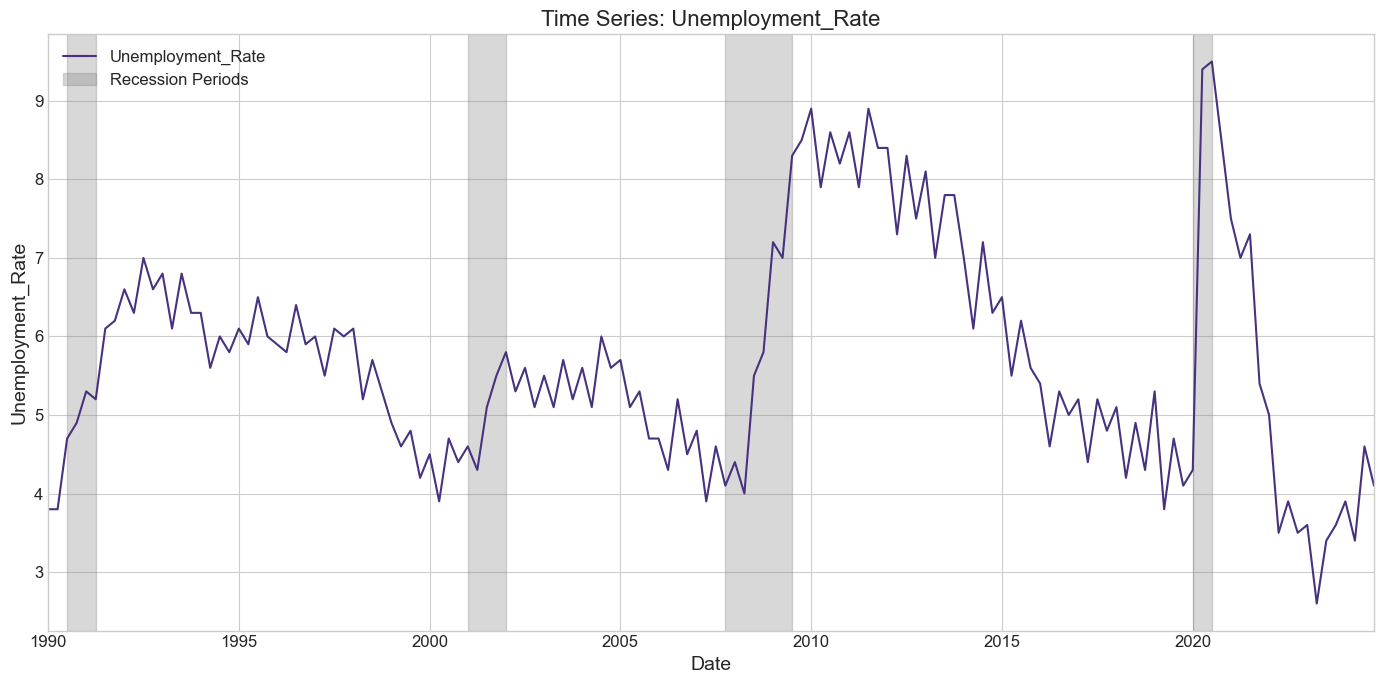

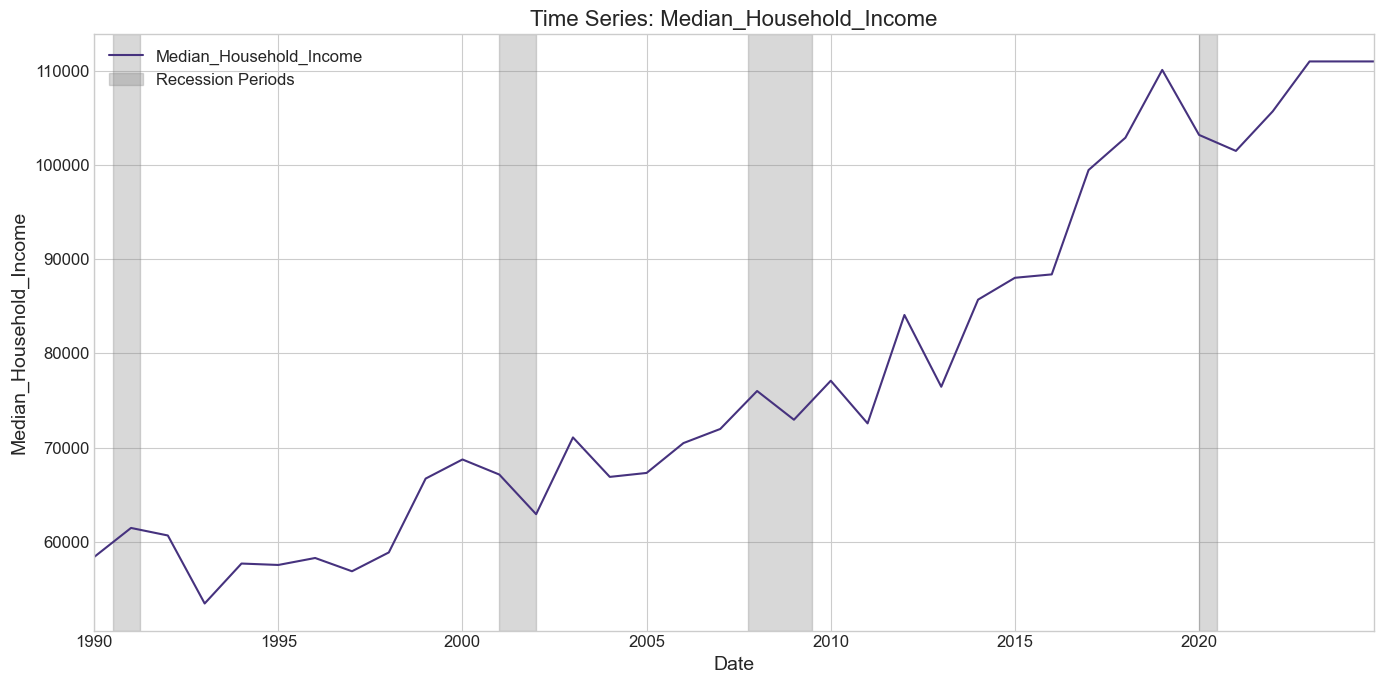

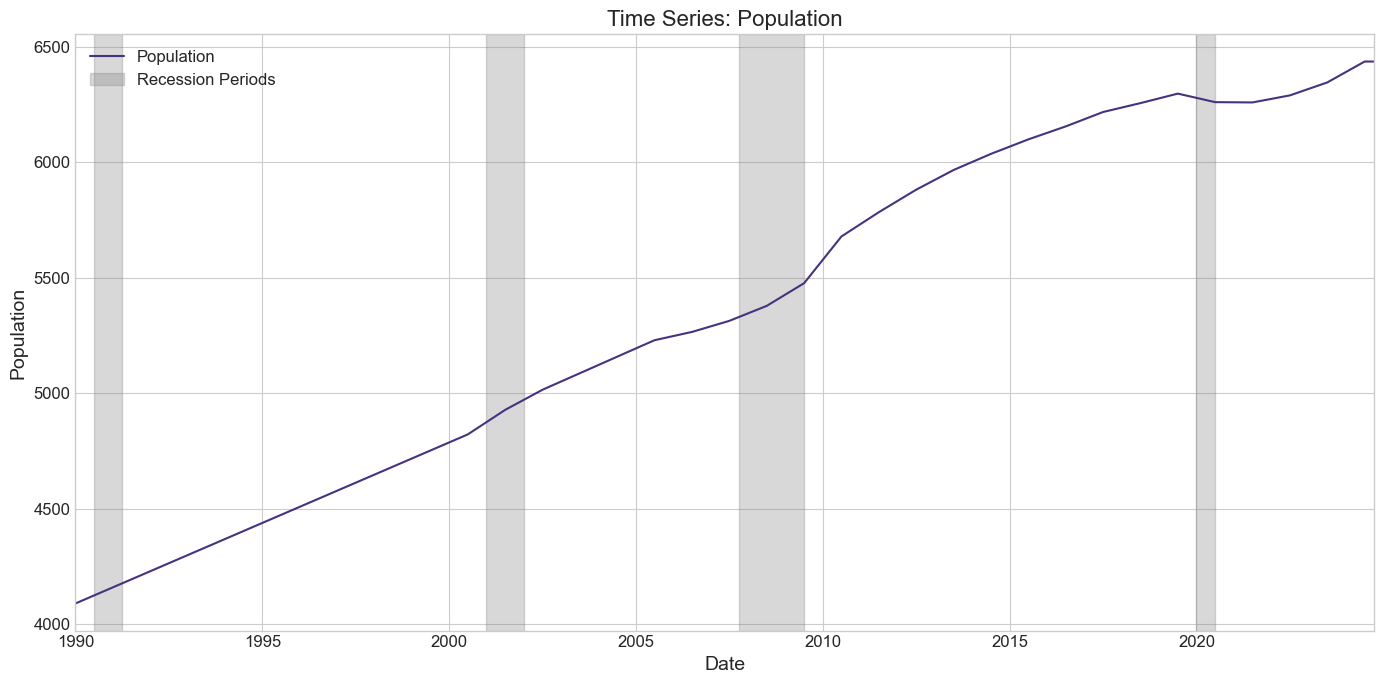

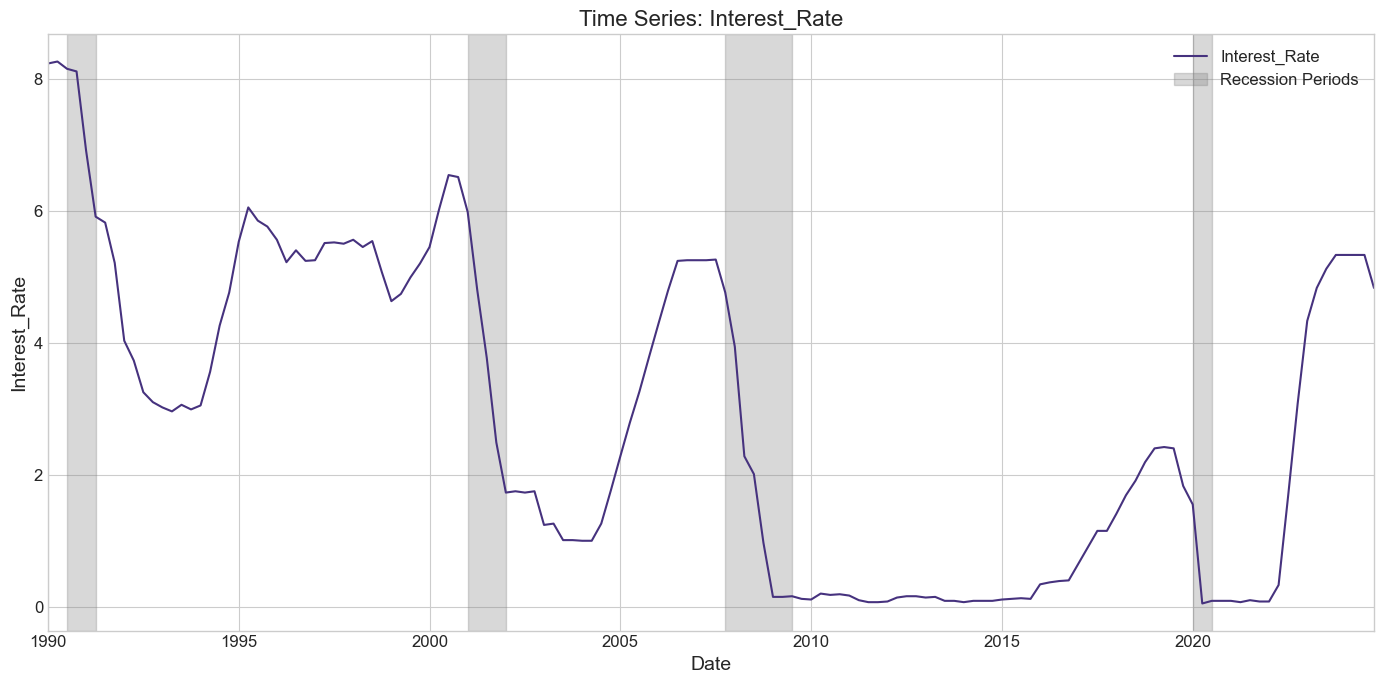

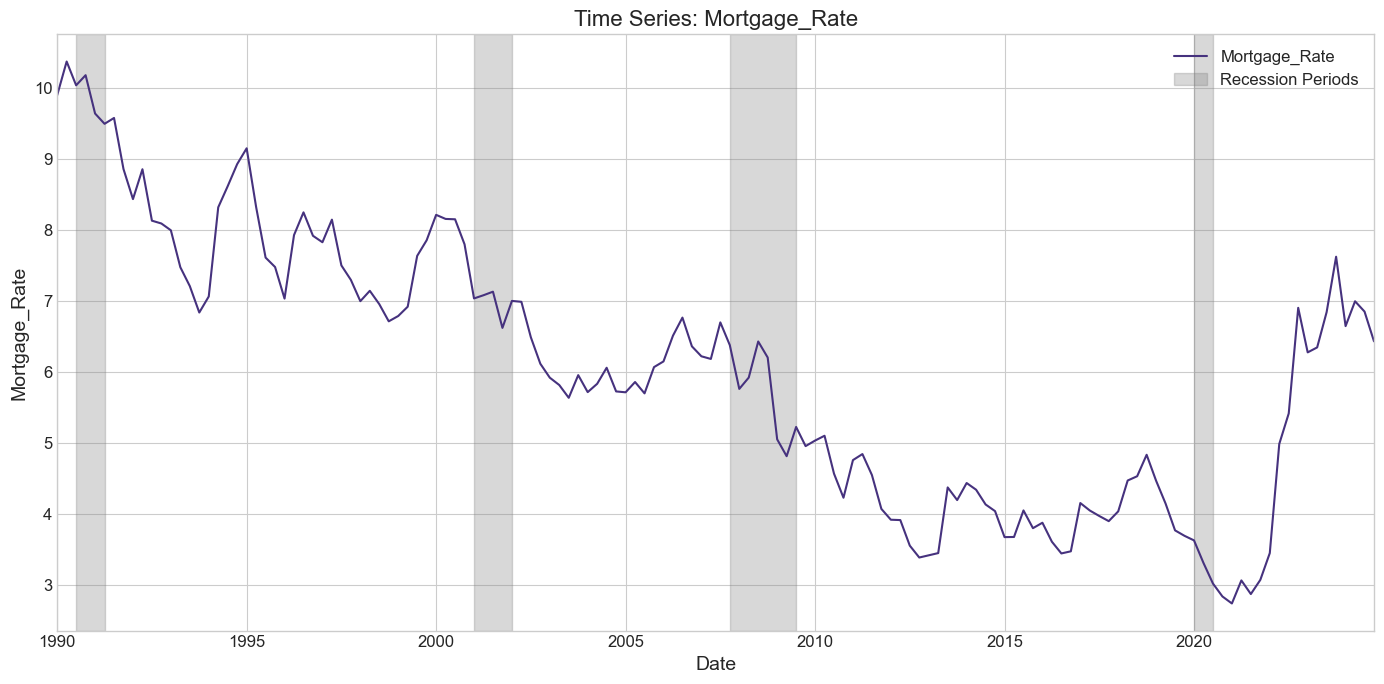

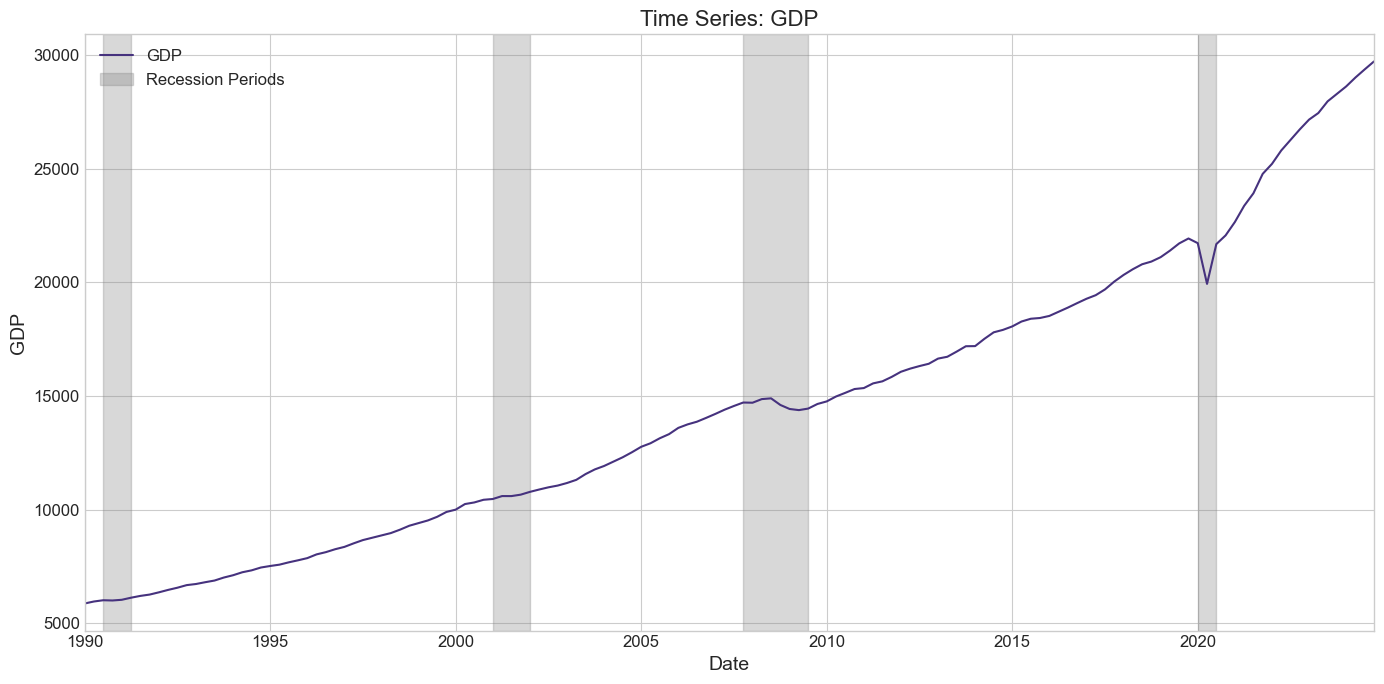


--- Detailed Time Series Plot for Target Variable (House_Index) ---


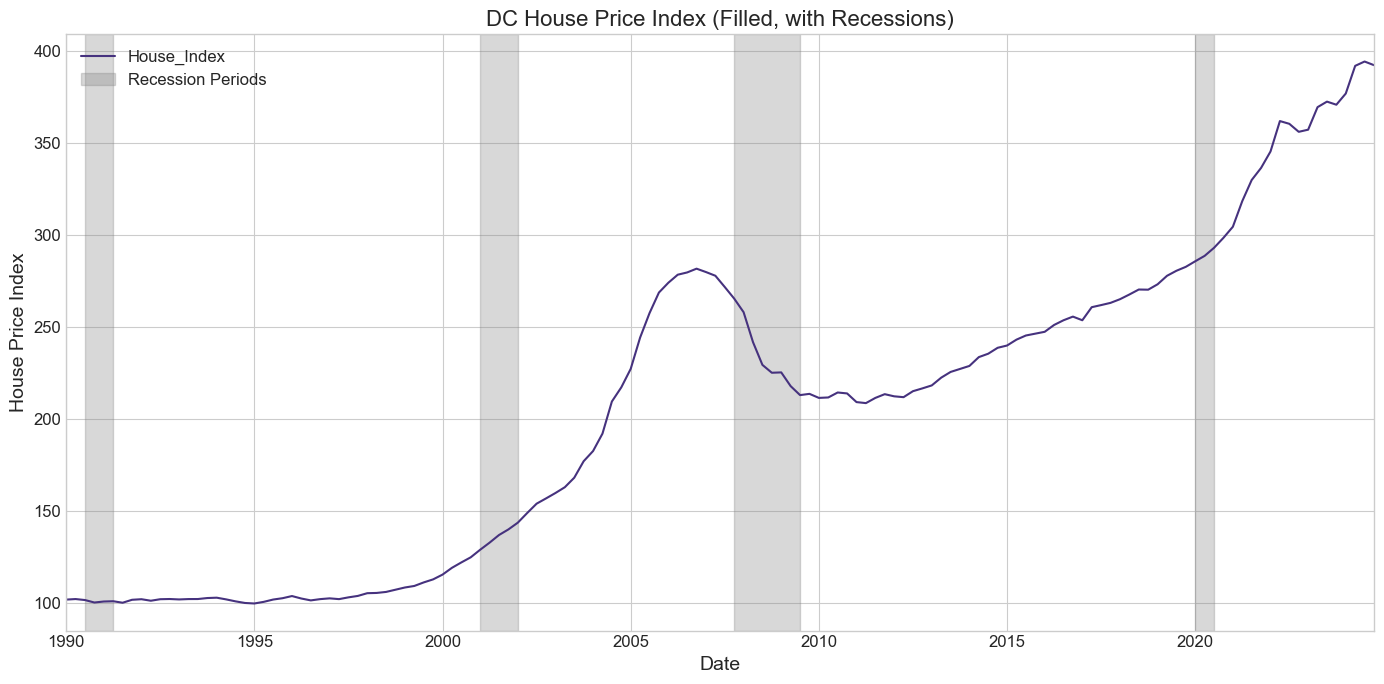

In [5]:
# --- Step 2: Time Series Visualization ---

# Define recession periods based on NBER dates, aligned to quarters for shading
# Format: (start_date, end_date, label)
# Start date aligned to the beginning of the quarter containing the peak month
# End date aligned to the beginning of the quarter AFTER the trough month
recession_periods = [
    ('1990-07-01', '1991-04-01', '1990-91 Recession'), # July 1990 - March 1991
    ('2001-01-01', '2002-01-01', '2001 Recession'),   # March 2001 - Nov 2001
    ('2007-10-01', '2009-07-01', 'Great Recession'), # Dec 2007 - June 2009
    ('2020-01-01', '2020-07-01', 'COVID-19 Recession') # Feb 2020 - April 2020
]
# Convert string dates to datetime objects
recession_periods_dt = [(pd.to_datetime(start), pd.to_datetime(end), label) for start, end, label in recession_periods]

# 2.1 Contextual Plotting Function
def plot_time_series_with_context(data, column_name, recession_periods_dt, title=None, ylabel=None):
    """
    Plots a time series with shaded recession periods.

    Args:
        data (pd.Series or pd.DataFrame): Time series data with a DatetimeIndex.
        column_name (str): The column to plot if data is a DataFrame.
        recession_periods_dt (list): List of tuples (start_dt, end_dt, label).
        title (str, optional): Plot title. Defaults to column_name.
        ylabel (str, optional): Y-axis label. Defaults to column_name.
    """
    if isinstance(data, pd.DataFrame):
        series_to_plot = data[column_name]
    elif isinstance(data, pd.Series):
        series_to_plot = data
    else:
        raise TypeError("Input data must be a pandas Series or DataFrame.")

    if title is None:
        title = f'Time Series: {column_name}'
    if ylabel is None:
        ylabel = column_name

    fig, ax = plt.subplots(figsize=(14, 7))
    series_to_plot.plot(ax=ax, label=column_name, color=sns.color_palette('viridis')[0])

    # Add shaded recession periods
    for start, end, label in recession_periods_dt:
        ax.axvspan(start, end, color='grey', alpha=0.3, label='_nolegend_') # Use _nolegend_ to avoid duplicate labels

    # Add a single legend entry for recessions
    if recession_periods_dt:
         ax.fill_between([], [], color='grey', alpha=0.3, label='Recession Periods')


    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xlabel('Date')
    ax.legend()
    plt.tight_layout()
    plt.show()

# 2.2 Plot All Variables
print("\n--- Time Series Plots for All Variables (with Recessions) ---")
for col in df_filled.columns:
    plot_time_series_with_context(df_filled, col, recession_periods_dt)

# 2.3 Plot Target Variable Separately
print("\n--- Detailed Time Series Plot for Target Variable (House_Index) ---")
plot_time_series_with_context(df_filled, 'House_Index', recession_periods_dt,
                               title='DC House Price Index (Filled, with Recessions)',
                               ylabel='House Price Index')


=== Stationarity Analysis Results ===


===== Analyzing: House_Index =====

--- ADF Test for House_Index ---
ADF Statistic: -0.1986
p-value: 0.9387
Critical Values:
   1%: -3.4801
   5%: -2.8834
   10%: -2.5784
Result: Fail to reject the null hypothesis (H0). 'House_Index' is likely non-stationary.

--- KPSS Test for House_Index (regression='ct') ---
KPSS Statistic: 0.1172
p-value: 0.1000
Number of Lags Used: 6
Critical Values:
   10%: 0.1190
   5%: 0.1460
   2.5%: 0.1760
   1%: 0.2160
Result: Fail to reject the null hypothesis (H0). 'House_Index' is likely stationary (around a ct).


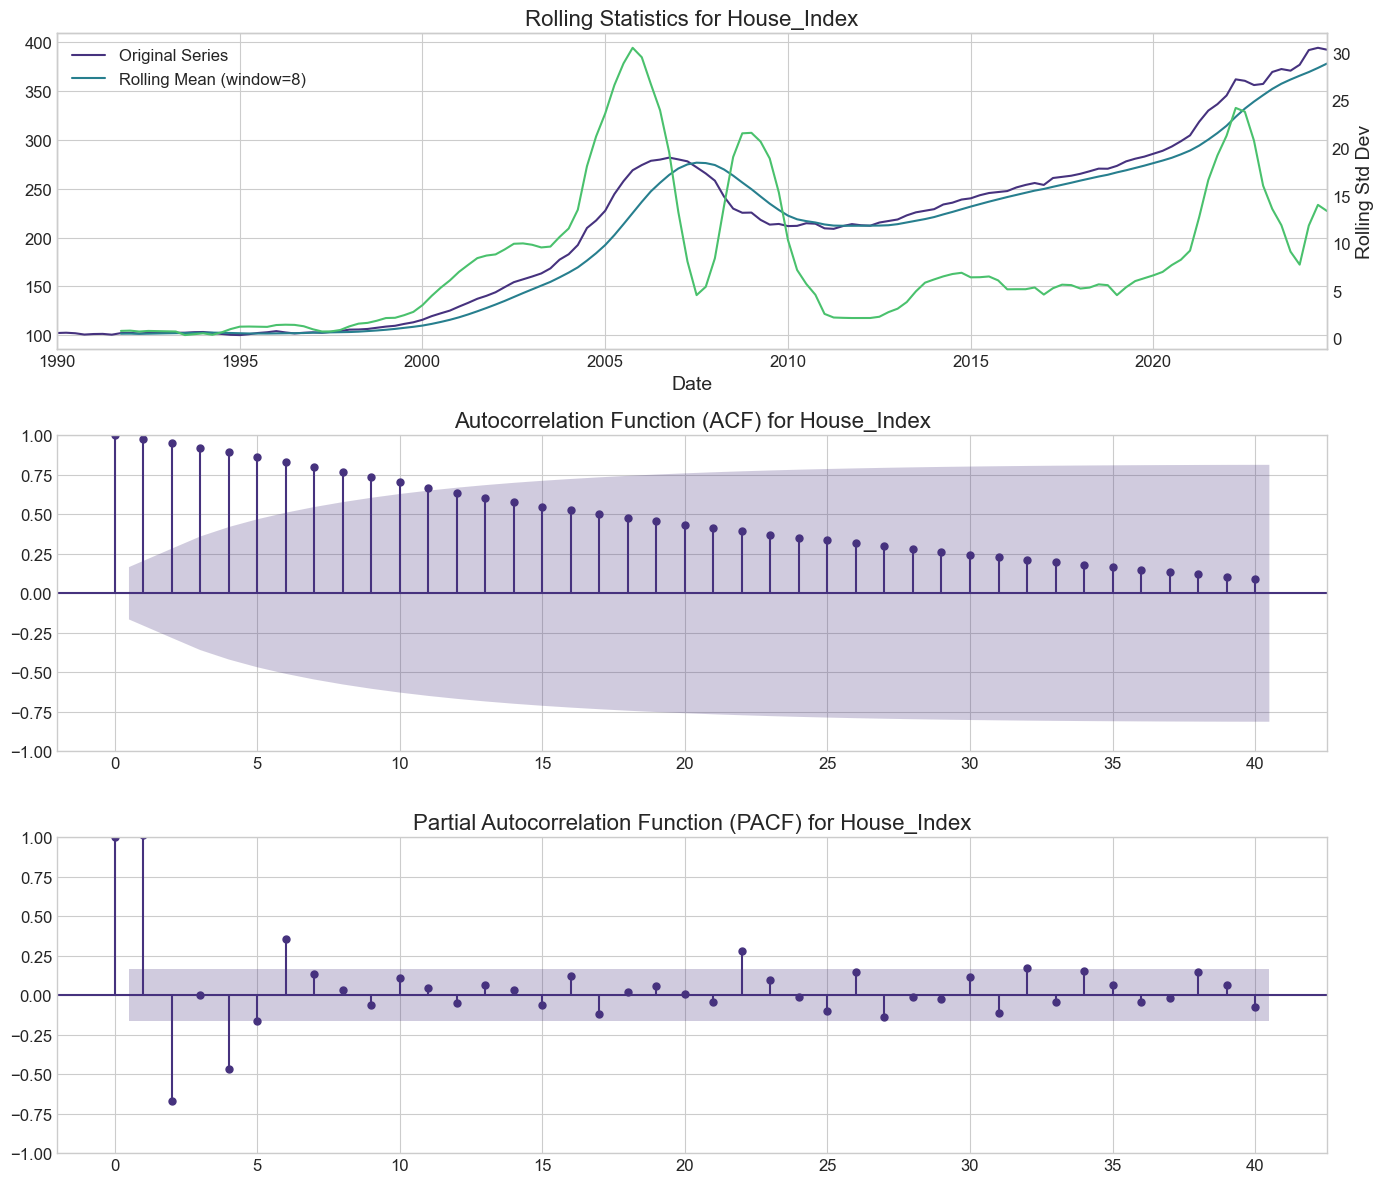



===== Analyzing: CPI =====

--- ADF Test for CPI ---
ADF Statistic: 1.3565
p-value: 0.9969
Critical Values:
   1%: -3.4797
   5%: -2.8832
   10%: -2.5783
Result: Fail to reject the null hypothesis (H0). 'CPI' is likely non-stationary.

--- KPSS Test for CPI (regression='ct') ---
KPSS Statistic: 0.1385
p-value: 0.0640
Number of Lags Used: 6
Critical Values:
   10%: 0.1190
   5%: 0.1460
   2.5%: 0.1760
   1%: 0.2160
Result: Fail to reject the null hypothesis (H0). 'CPI' is likely stationary (around a ct).


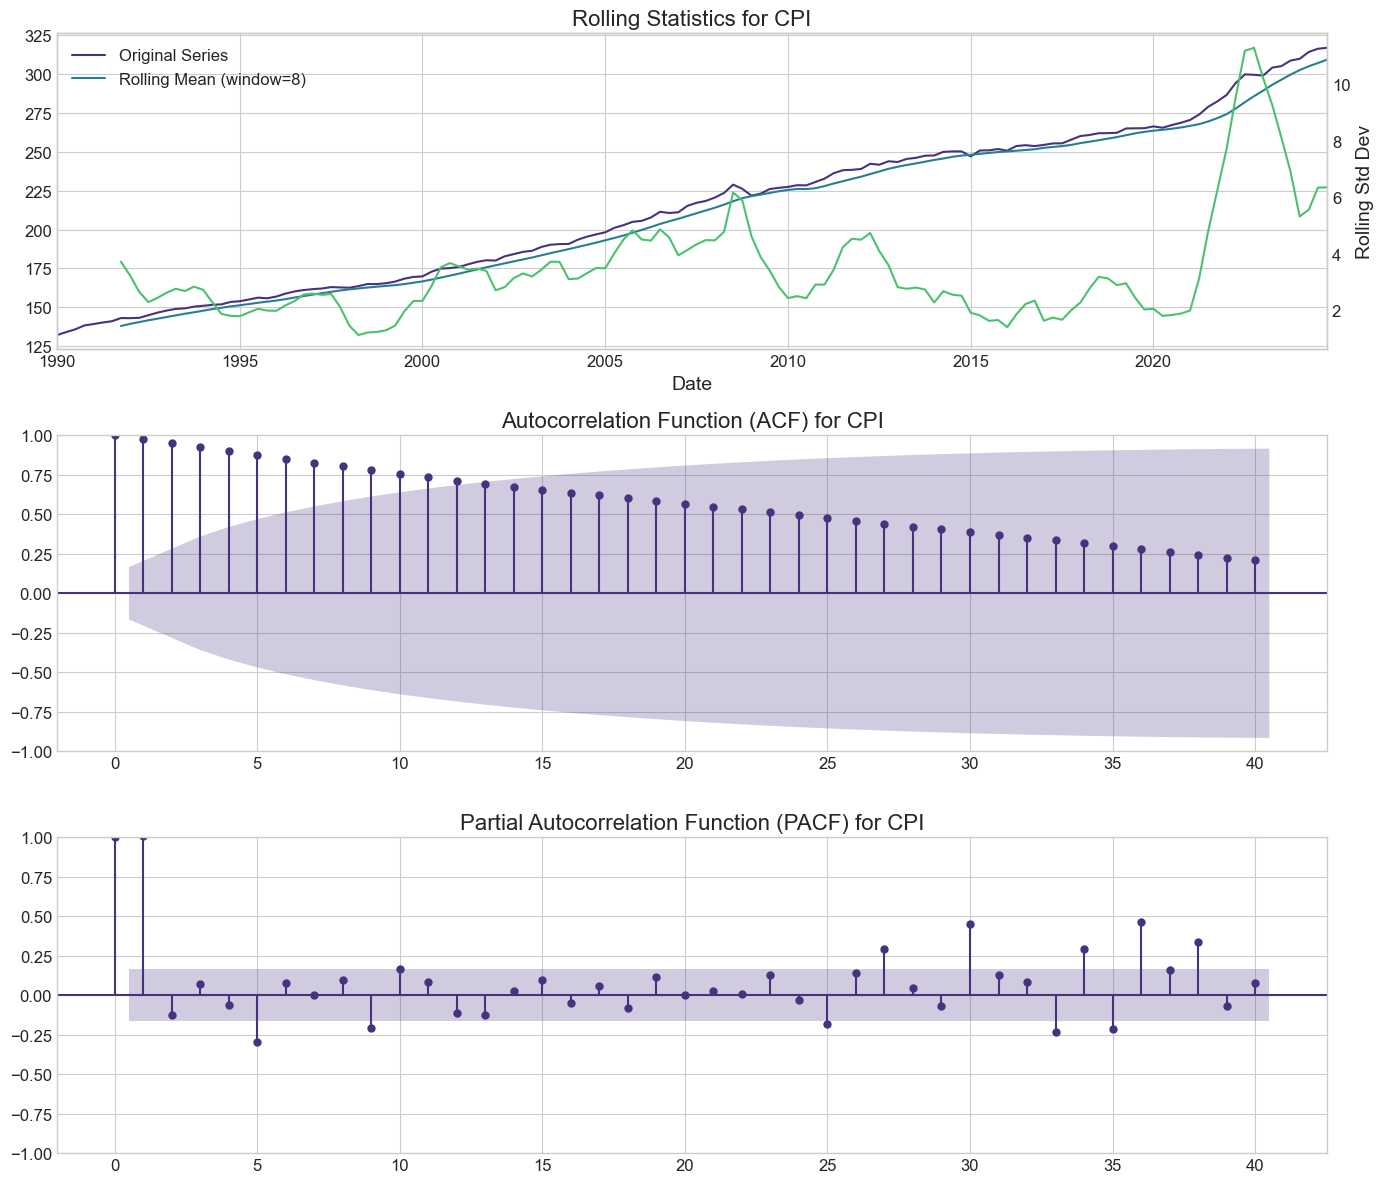



===== Analyzing: Poverty_Rate =====

--- ADF Test for Poverty_Rate ---
ADF Statistic: -2.3026
p-value: 0.1711
Critical Values:
   1%: -3.4801
   5%: -2.8834
   10%: -2.5784
Result: Fail to reject the null hypothesis (H0). 'Poverty_Rate' is likely non-stationary.

--- KPSS Test for Poverty_Rate (regression='c') ---
KPSS Statistic: 0.5007
p-value: 0.0415
Number of Lags Used: 6
Critical Values:
   10%: 0.3470
   5%: 0.4630
   2.5%: 0.5740
   1%: 0.7390
Result: Reject the null hypothesis (H0). 'Poverty_Rate' is likely non-stationary.


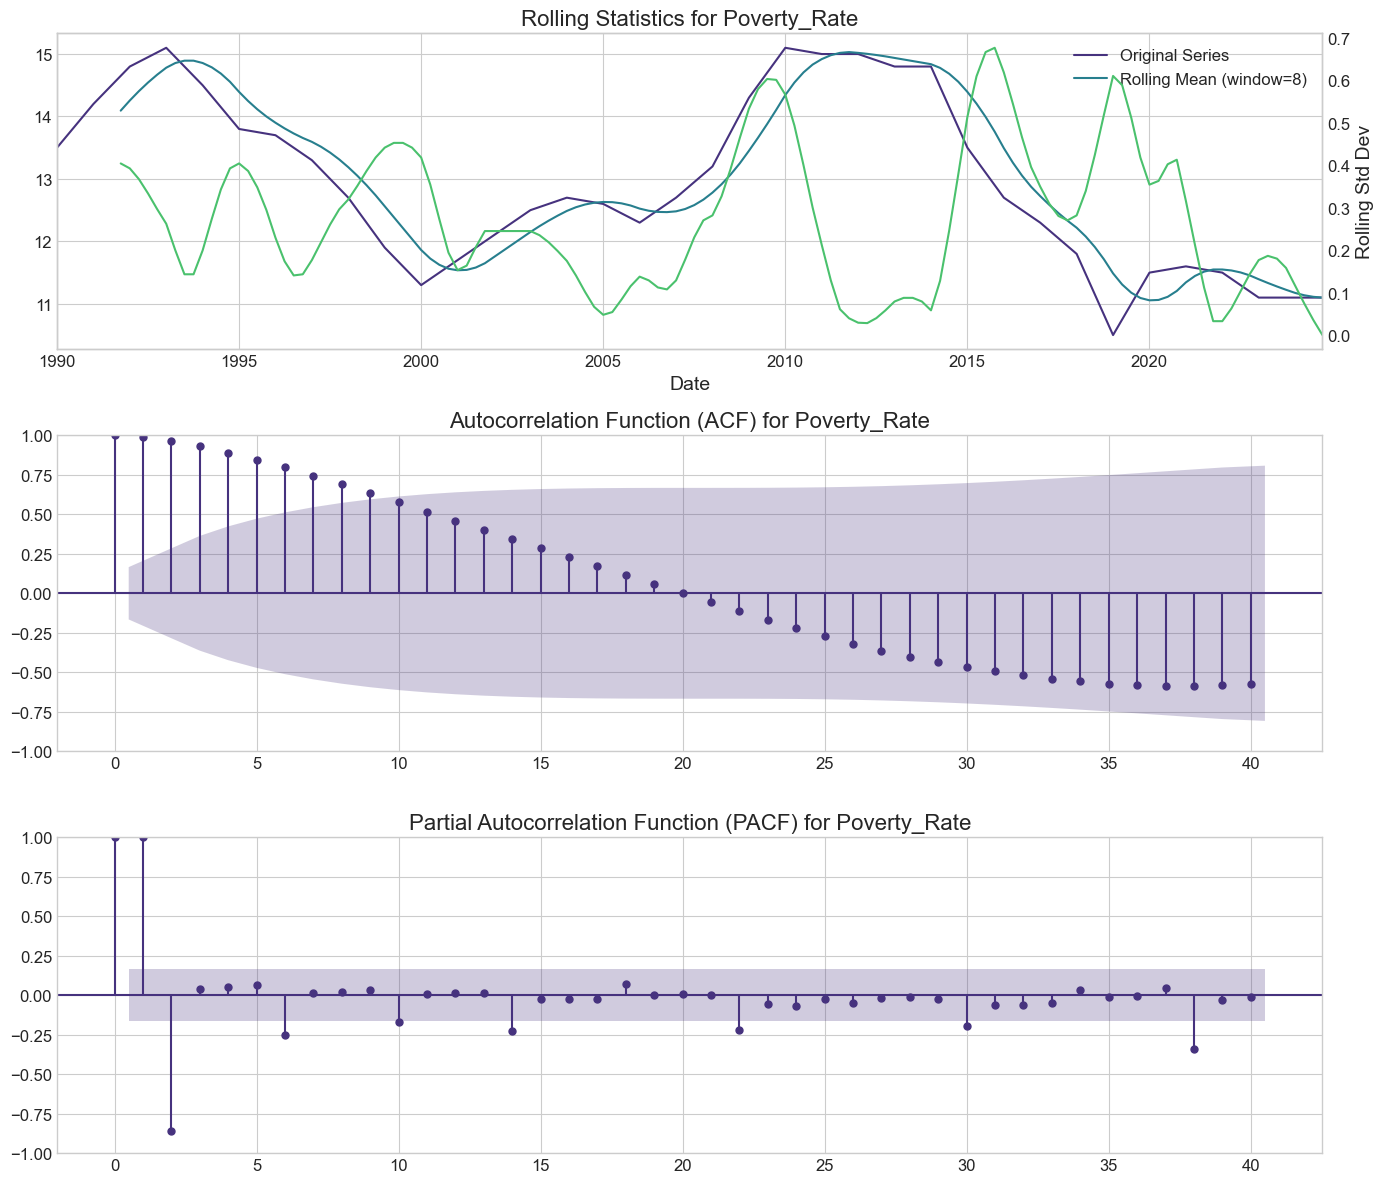



===== Analyzing: Unemployment_Rate =====

--- ADF Test for Unemployment_Rate ---
ADF Statistic: -3.3242
p-value: 0.0138
Critical Values:
   1%: -3.4797
   5%: -2.8832
   10%: -2.5783
Result: Reject the null hypothesis (H0). 'Unemployment_Rate' is likely stationary.

--- KPSS Test for Unemployment_Rate (regression='c') ---
KPSS Statistic: 0.1332
p-value: 0.1000
Number of Lags Used: 6
Critical Values:
   10%: 0.3470
   5%: 0.4630
   2.5%: 0.5740
   1%: 0.7390
Result: Fail to reject the null hypothesis (H0). 'Unemployment_Rate' is likely stationary (around a c).


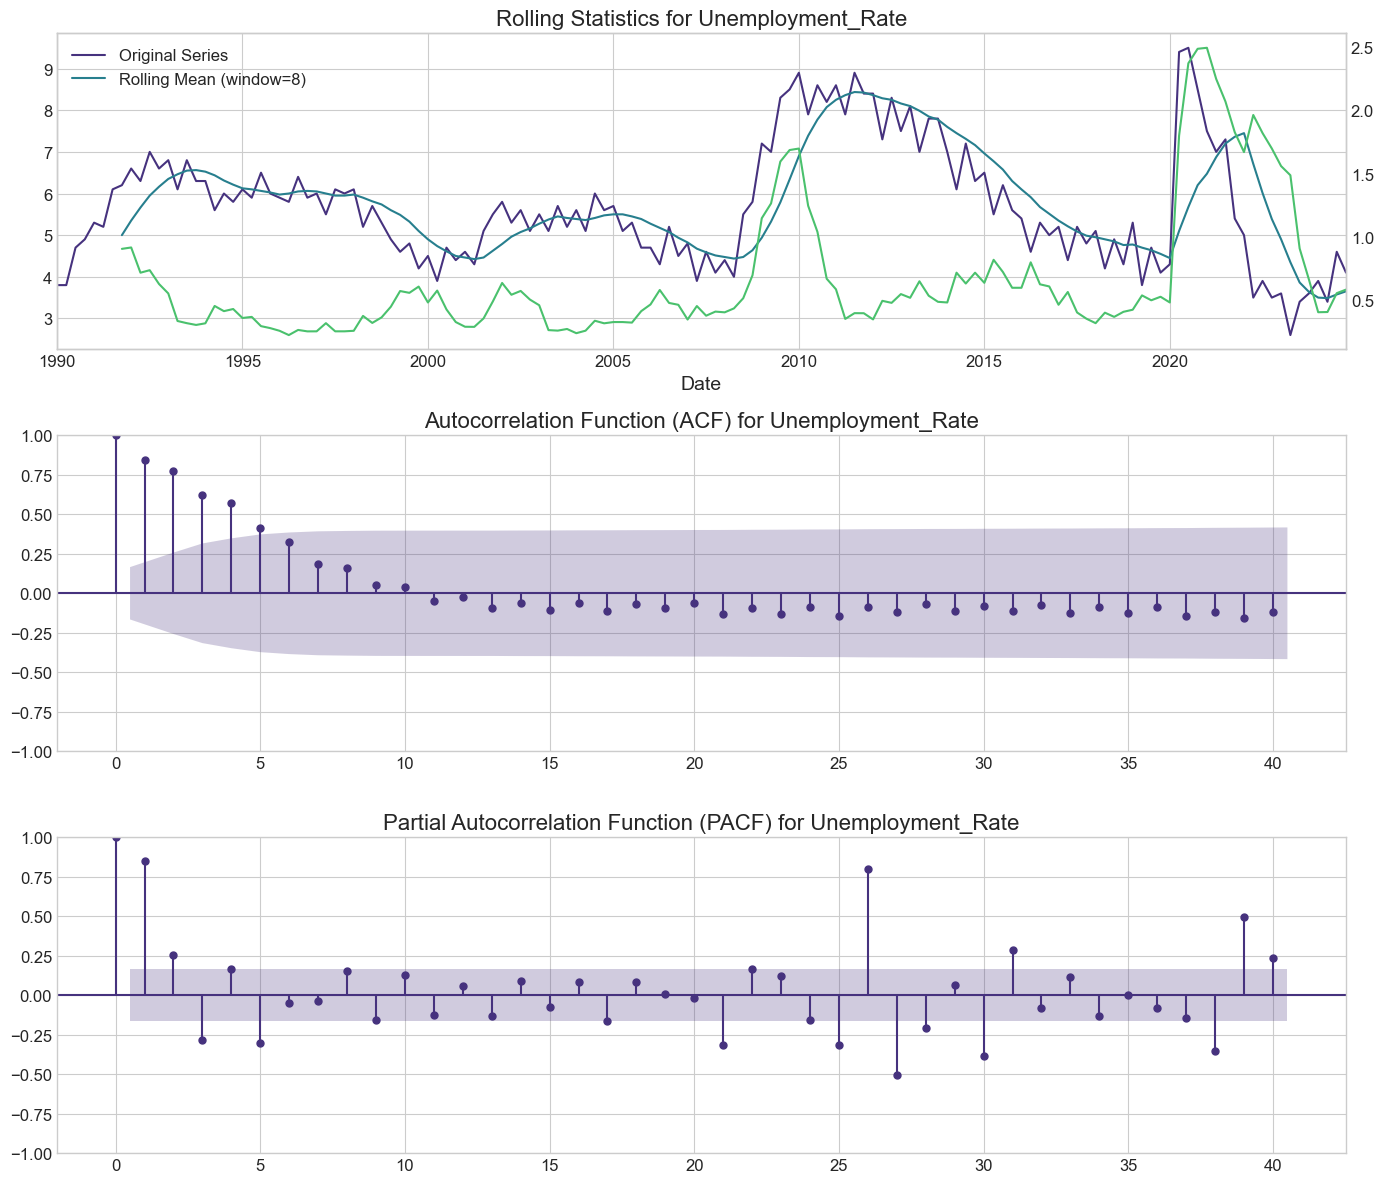



===== Analyzing: Median_Household_Income =====

--- ADF Test for Median_Household_Income ---
ADF Statistic: 0.5126
p-value: 0.9853
Critical Values:
   1%: -3.4833
   5%: -2.8848
   10%: -2.5792
Result: Fail to reject the null hypothesis (H0). 'Median_Household_Income' is likely non-stationary.

--- KPSS Test for Median_Household_Income (regression='ct') ---
KPSS Statistic: 0.3904
p-value: 0.0100
Number of Lags Used: 6
Critical Values:
   10%: 0.1190
   5%: 0.1460
   2.5%: 0.1760
   1%: 0.2160
Result: Reject the null hypothesis (H0). 'Median_Household_Income' is likely non-stationary.


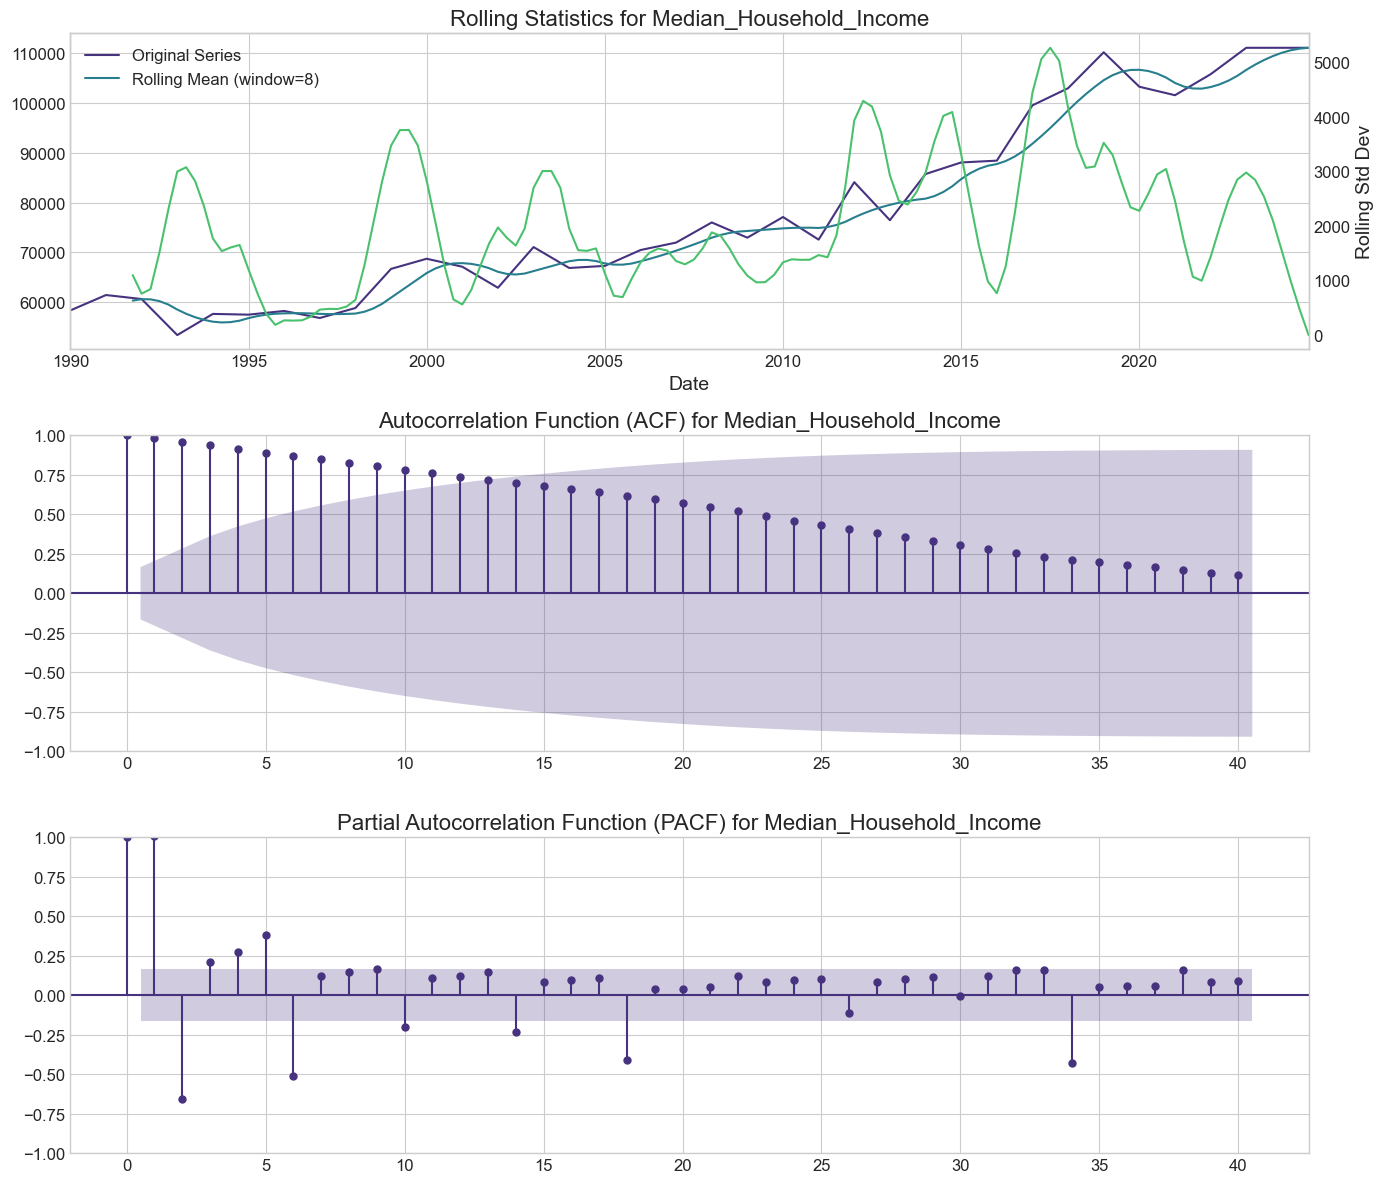



===== Analyzing: Population =====

--- ADF Test for Population ---
ADF Statistic: -1.4334
p-value: 0.5662
Critical Values:
   1%: -3.4786
   5%: -2.8827
   10%: -2.5781
Result: Fail to reject the null hypothesis (H0). 'Population' is likely non-stationary.

--- KPSS Test for Population (regression='ct') ---
KPSS Statistic: 0.2422
p-value: 0.0100
Number of Lags Used: 6
Critical Values:
   10%: 0.1190
   5%: 0.1460
   2.5%: 0.1760
   1%: 0.2160
Result: Reject the null hypothesis (H0). 'Population' is likely non-stationary.


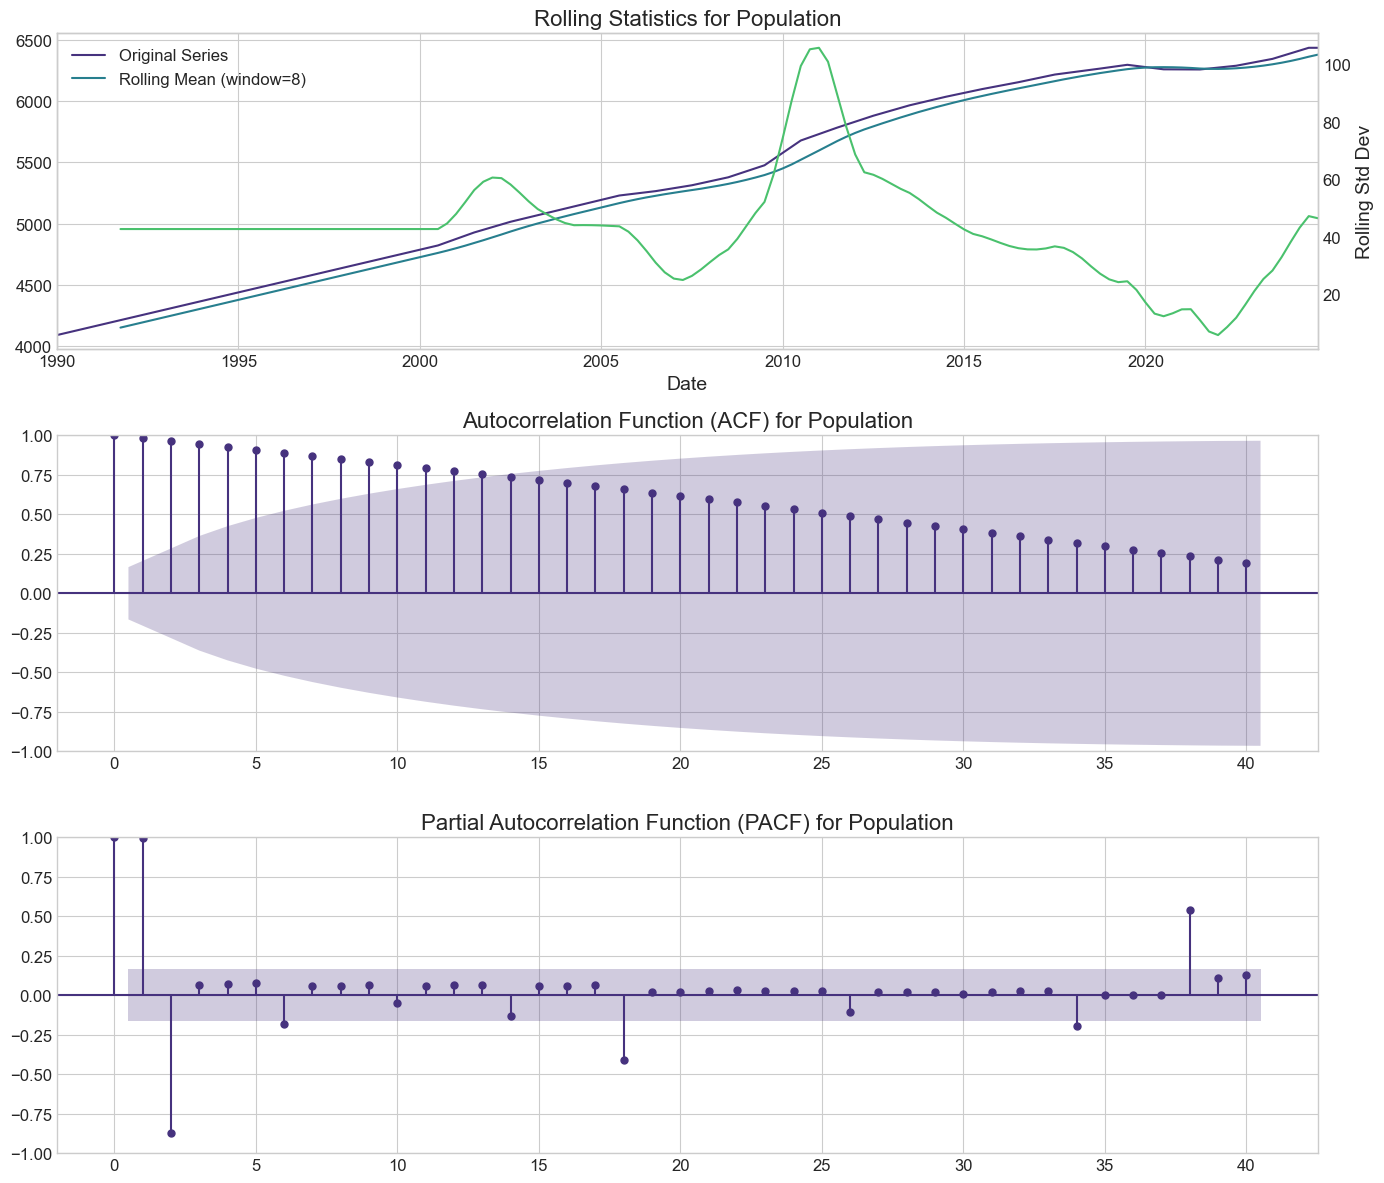



===== Analyzing: Interest_Rate =====

--- ADF Test for Interest_Rate ---
ADF Statistic: -3.4872
p-value: 0.0083
Critical Values:
   1%: -3.4790
   5%: -2.8829
   10%: -2.5781
Result: Reject the null hypothesis (H0). 'Interest_Rate' is likely stationary.

--- KPSS Test for Interest_Rate (regression='c') ---
KPSS Statistic: 1.0091
p-value: 0.0100
Number of Lags Used: 6
Critical Values:
   10%: 0.3470
   5%: 0.4630
   2.5%: 0.5740
   1%: 0.7390
Result: Reject the null hypothesis (H0). 'Interest_Rate' is likely non-stationary.


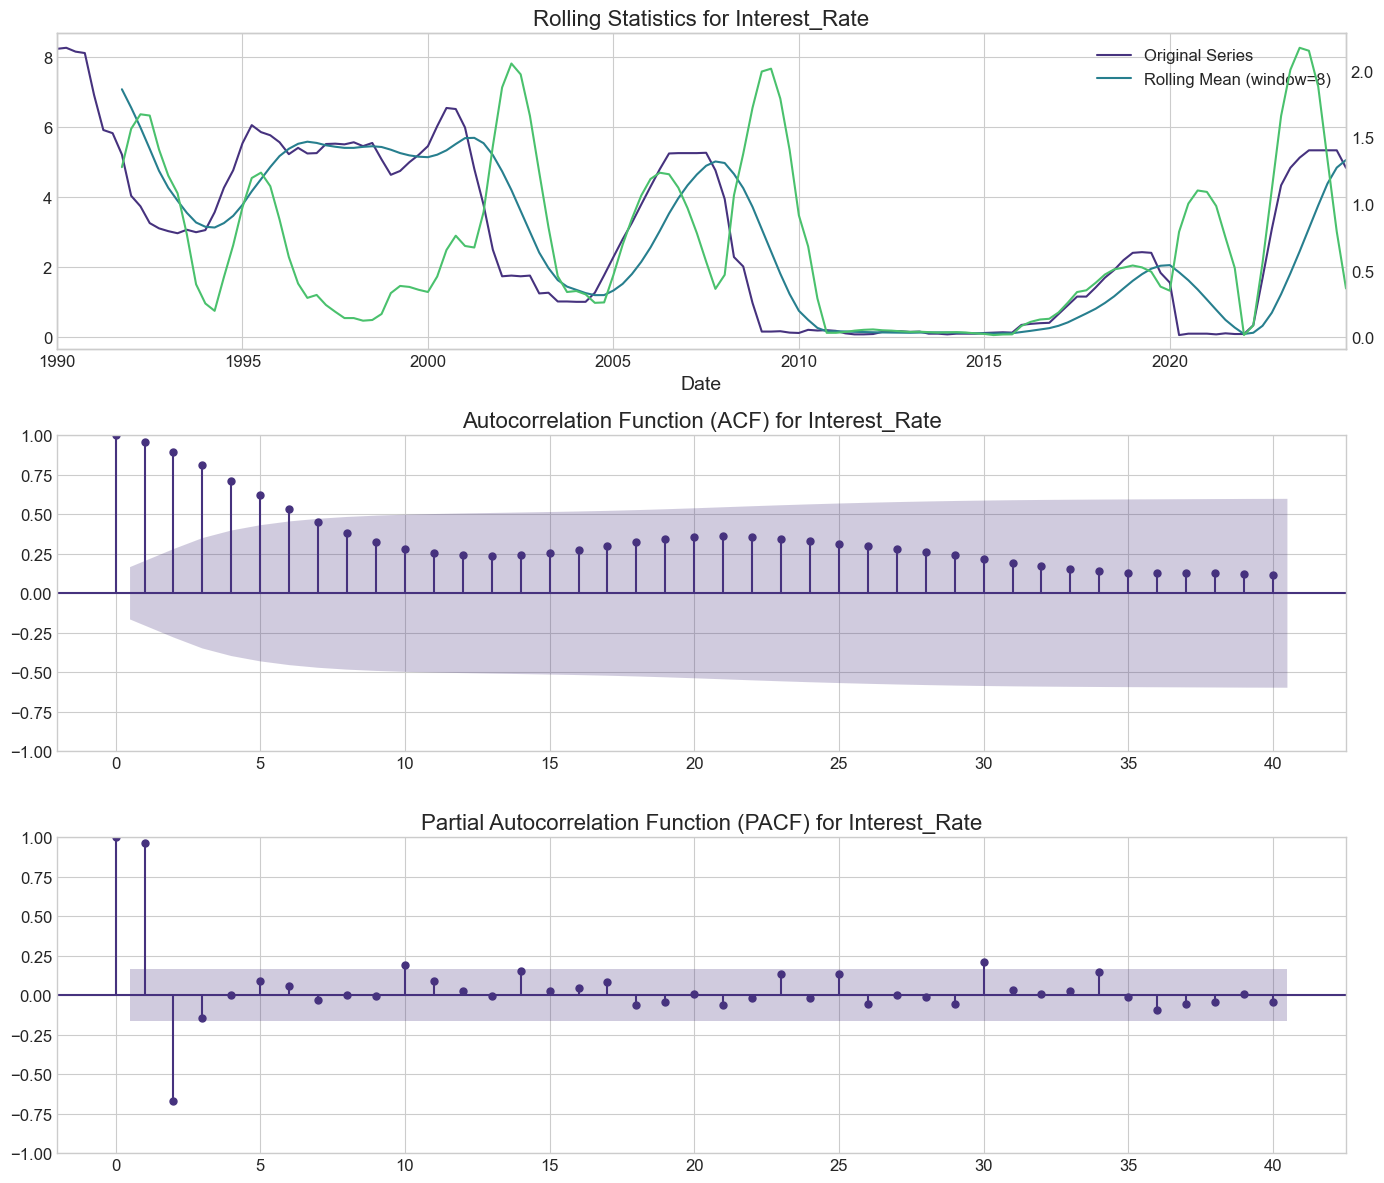



===== Analyzing: Mortgage_Rate =====

--- ADF Test for Mortgage_Rate ---
ADF Statistic: -2.1520
p-value: 0.2241
Critical Values:
   1%: -3.4783
   5%: -2.8826
   10%: -2.5780
Result: Fail to reject the null hypothesis (H0). 'Mortgage_Rate' is likely non-stationary.

--- KPSS Test for Mortgage_Rate (regression='c') ---
KPSS Statistic: 1.5805
p-value: 0.0100
Number of Lags Used: 6
Critical Values:
   10%: 0.3470
   5%: 0.4630
   2.5%: 0.5740
   1%: 0.7390
Result: Reject the null hypothesis (H0). 'Mortgage_Rate' is likely non-stationary.


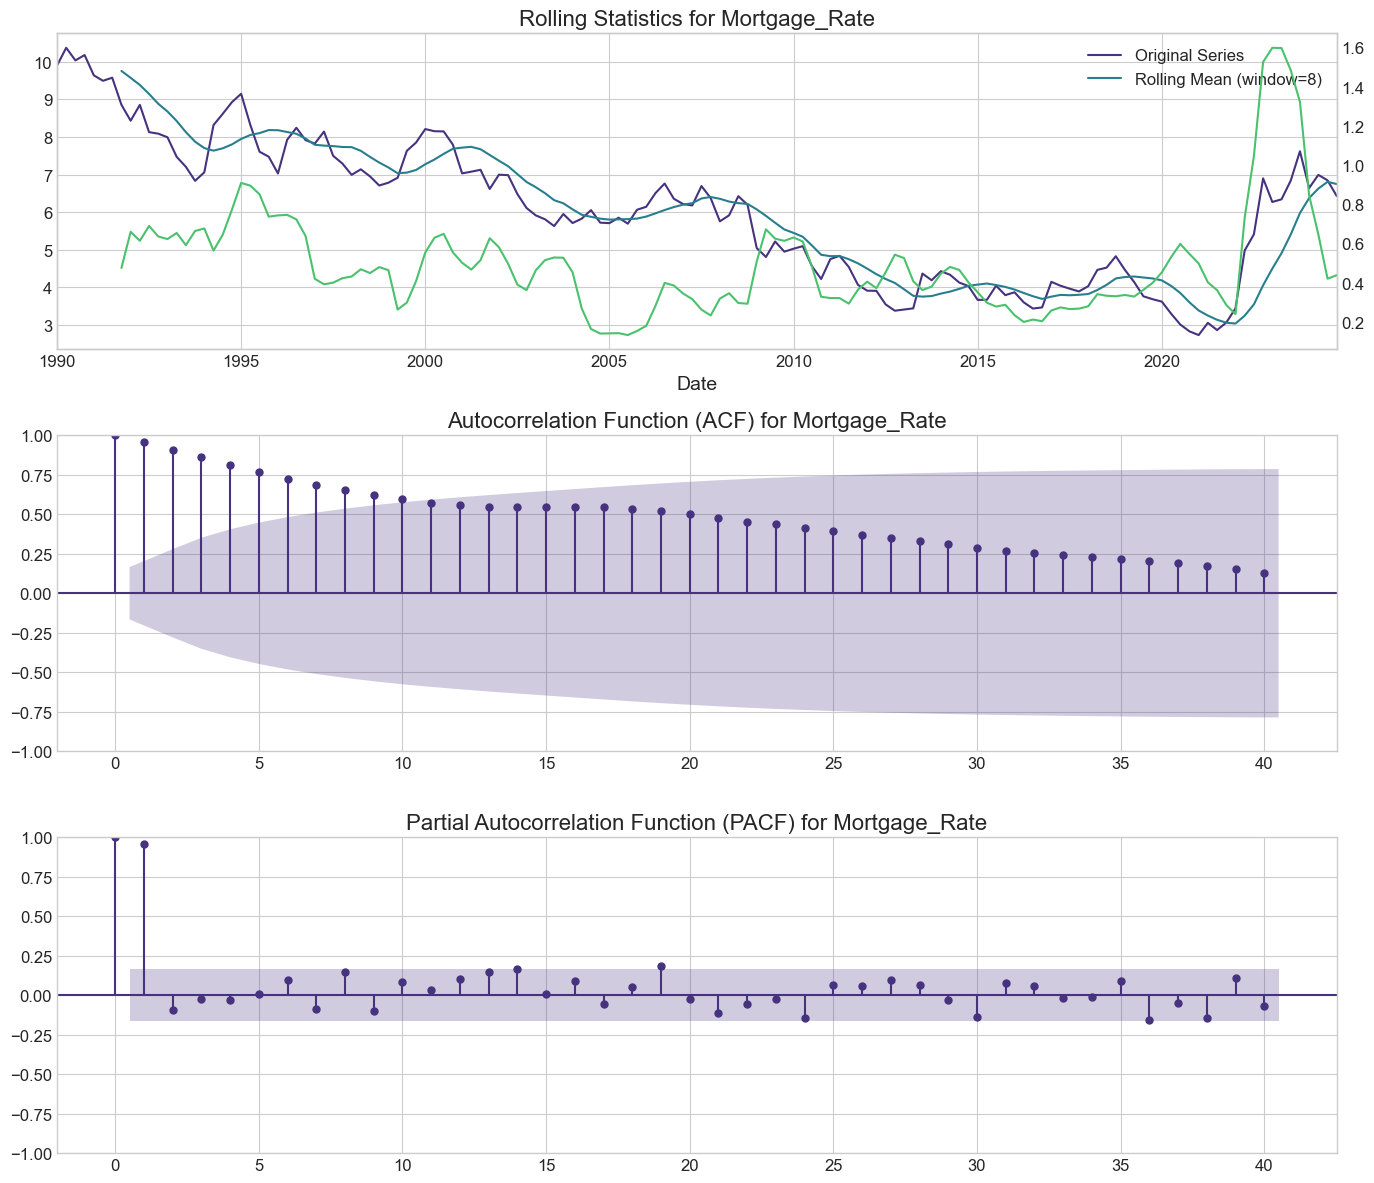



===== Analyzing: GDP =====

--- ADF Test for GDP ---
ADF Statistic: 4.0182
p-value: 1.0000
Critical Values:
   1%: -3.4783
   5%: -2.8826
   10%: -2.5780
Result: Fail to reject the null hypothesis (H0). 'GDP' is likely non-stationary.

--- KPSS Test for GDP (regression='ct') ---
KPSS Statistic: 0.3486
p-value: 0.0100
Number of Lags Used: 6
Critical Values:
   10%: 0.1190
   5%: 0.1460
   2.5%: 0.1760
   1%: 0.2160
Result: Reject the null hypothesis (H0). 'GDP' is likely non-stationary.


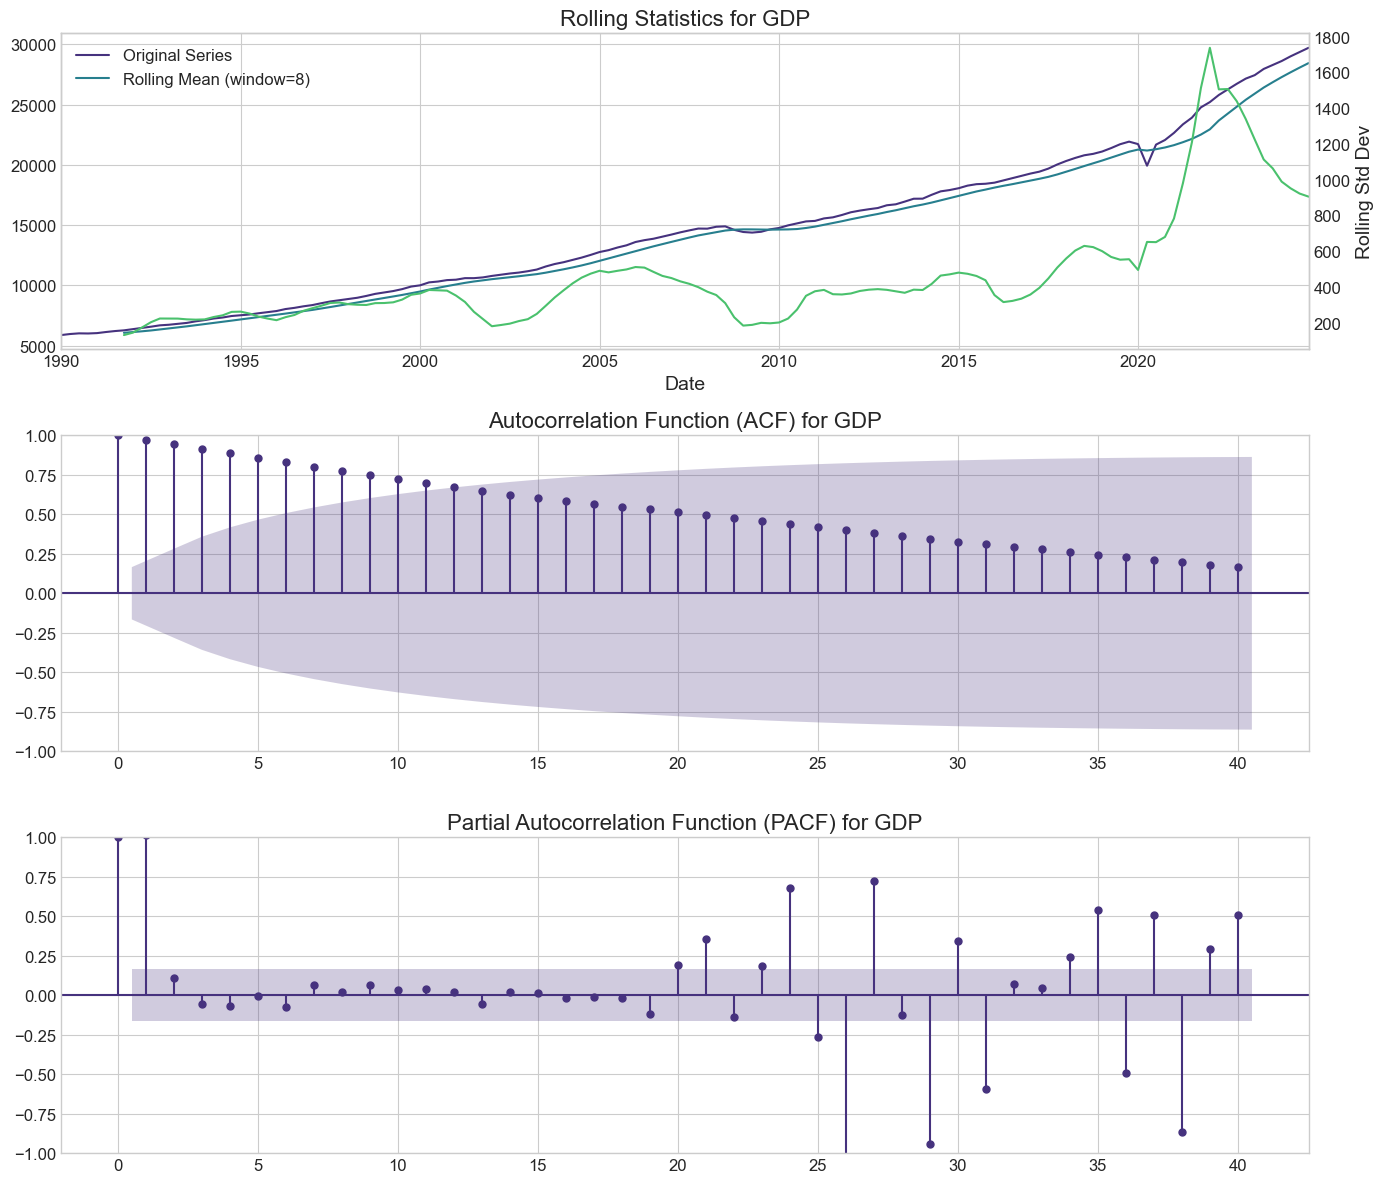



--- Stationarity Summary ---
House_Index: Conflicting Results (Likely Non-Stationary)
CPI: Conflicting Results (Likely Non-Stationary)
Poverty_Rate: Likely Non-Stationary
Unemployment_Rate: Likely Stationary
Median_Household_Income: Likely Non-Stationary
Population: Likely Non-Stationary
Interest_Rate: Conflicting Results (Likely Non-Stationary)
Mortgage_Rate: Likely Non-Stationary
GDP: Likely Non-Stationary


In [6]:
# --- Step 3: Stationarity Analysis ---
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# 3.1 Testing Functions

def perform_adf_test(series, series_name):
    """Performs ADF test and prints results."""
    print(f"\n--- ADF Test for {series_name} ---")
    # Drop NaNs that might exist from differencing/transformations later (though none expected here)
    result = adfuller(series.dropna())
    print(f'ADF Statistic: {result[0]:.4f}')
    print(f'p-value: {result[1]:.4f}')
    print('Critical Values:')
    for key, value in result[4].items():
        print(f'   {key}: {value:.4f}')

    if result[1] <= 0.05:
        print(f"Result: Reject the null hypothesis (H0). '{series_name}' is likely stationary.")
        return True
    else:
        print(f"Result: Fail to reject the null hypothesis (H0). '{series_name}' is likely non-stationary.")
        return False

def perform_kpss_test(series, series_name, regression='c'):
    """Performs KPSS test and prints results."""
    # regression : str{'c', 'ct'}
    # The null hypothesis for the KPSS test.
    # 'c': The data is stationary around a constant (level stationary).
    # 'ct': The data is stationary around a trend (trend stationary).
    print(f"\n--- KPSS Test for {series_name} (regression='{regression}') ---")
    # Note: KPSS test returns statistic, p-value, lags, critical values dict
    try:
      # Suppressing warnings specific to KPSS p-value interpolation
      with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        statistic, p_value, lags, critical_values = kpss(series.dropna(), regression=regression, nlags='auto')

      print(f'KPSS Statistic: {statistic:.4f}')
      print(f'p-value: {p_value:.4f}') # Often reported as <0.01 or >0.1
      print(f'Number of Lags Used: {lags}')
      print('Critical Values:')
      for key, value in critical_values.items():
          print(f'   {key}: {value:.4f}')

      # Interpretation: If statistic > critical value, reject H0 (series is non-stationary)
      # Or, if p_value < 0.05 (common threshold), reject H0.
      if p_value <= 0.05: # Using p-value for decision
          print(f"Result: Reject the null hypothesis (H0). '{series_name}' is likely non-stationary.")
          return False
      else:
          print(f"Result: Fail to reject the null hypothesis (H0). '{series_name}' is likely stationary (around a {regression}).")
          return True
    except Exception as e:
      print(f"KPSS test failed for {series_name}: {e}")
      return None # Indicate failure

def plot_stationarity_visuals(series, series_name, window=12):
    """Plots rolling statistics and ACF/PACF."""
    fig, axes = plt.subplots(3, 1, figsize=(14, 12)) # Increased height slightly

    # Rolling statistics
    rolling_mean = series.rolling(window=window).mean()
    rolling_std = series.rolling(window=window).std()
    series.plot(ax=axes[0], color=sns.color_palette('viridis')[0], label='Original Series')
    rolling_mean.plot(ax=axes[0], color=sns.color_palette('viridis')[2], label=f'Rolling Mean (window={window})')
    rolling_std.plot(ax=axes[0], color=sns.color_palette('viridis')[4], label=f'Rolling Std Dev (window={window})', secondary_y=True) # Plot std on secondary y-axis if scales differ greatly
    axes[0].set_title(f'Rolling Statistics for {series_name}')
    axes[0].legend(loc='best')
    # Adjust secondary y-axis label if used
    if rolling_std.max() / series.max() < 0.1 or series.max() / rolling_std.max() < 0.1 : # Heuristic check if scales differ significantly
        axes[0].right_ax.set_ylabel('Rolling Std Dev')


    # ACF plot
    # Use nans='conservative' or dropna() before plotting if needed
    try:
        plot_acf(series.dropna(), ax=axes[1], lags=40) # Use 40 lags to see decay pattern
        axes[1].set_title(f'Autocorrelation Function (ACF) for {series_name}')
    except Exception as e:
        axes[1].set_title(f'ACF Plot Failed for {series_name}: {e}')


    # PACF plot
    try:
        plot_pacf(series.dropna(), ax=axes[2], lags=40, method='ols') # 'ols' is common
        axes[2].set_title(f'Partial Autocorrelation Function (PACF) for {series_name}')
    except Exception as e:
         axes[2].set_title(f'PACF Plot Failed for {series_name}: {e}')


    plt.tight_layout()
    plt.show()

# 3.2 Systematic Testing
print("\n=== Stationarity Analysis Results ===")
stationarity_summary = {}

for col in df_filled.columns:
    print(f"\n\n===== Analyzing: {col} =====")
    series = df_filled[col]

    # Perform Tests
    adf_stationary = perform_adf_test(series, col)
    # Use 'ct' for KPSS if visual inspection suggested a strong trend, else 'c'
    kpss_regression = 'ct' if col in ['House_Index', 'CPI', 'Median_Household_Income', 'Population', 'GDP'] else 'c'
    kpss_stationary = perform_kpss_test(series, col, regression=kpss_regression)

    # Summarize
    if adf_stationary and kpss_stationary:
        stationarity_summary[col] = 'Likely Stationary'
    elif not adf_stationary and not kpss_stationary:
        stationarity_summary[col] = 'Likely Non-Stationary'
    else: # Conflicting results
        stationarity_summary[col] = 'Conflicting Results (Likely Non-Stationary)'
        print(f"Warning: Conflicting stationarity results for {col}. ADF Stationary: {adf_stationary}, KPSS Stationary: {kpss_stationary}. Assuming Non-Stationary for safety.")

    # Plot Visuals
    plot_stationarity_visuals(series, col, window=8) # Using window=8 (2 years for quarterly data)


print("\n\n--- Stationarity Summary ---")
for col, result in stationarity_summary.items():
    print(f"{col}: {result}")

In [9]:
# --- Step 4 Correction: Create the final stationary DataFrame ---

# Identify non-stationary variables from Step 3 summary
# Treating conflicting results as non-stationary
non_stationary_vars = [col for col, result in stationarity_summary.items() if 'Non-Stationary' in result or 'Conflicting' in result]
stationary_vars = [col for col, result in stationarity_summary.items() if 'Stationary' in result]

# Get the index after differencing (index of df_filled excluding the first date)
final_index = df_filled.index[1:]

# Initialize the corrected DataFrame with the final index
df_transformed_corrected = pd.DataFrame(index=final_index)

# Add the differenced versions of non-stationary variables
for col in non_stationary_vars:
    # Calculate difference and align to the final index
    diff_series = df_filled[col].diff().loc[final_index]
    df_transformed_corrected[f'{col}_diff'] = diff_series

# Add the original stationary variables, aligned to the final index
for col in stationary_vars:
     # Ensure we don't overwrite if a variable was somehow listed in both (unlikely here)
    if col not in non_stationary_vars: # Check if it's ONLY stationary
        original_series = df_filled[col].loc[final_index]
        df_transformed_corrected[col] = original_series
    # If a variable is in stationary_vars but also had conflicting results (e.g., Interest_Rate)
    # it would have been differenced above. We prioritize the differenced version
    # based on our initial decision to treat conflicts as non-stationary.
    # We only add original variables here if they were *clearly* stationary in Step 3.
    # Example: Unemployment_Rate

# Re-verify columns (ensure no originals like 'House_Index' are present, only 'House_Index_diff')
# Let's refine the stationary_vars list to only include those that were *not* marked conflicting
clearly_stationary_vars = [col for col in stationary_vars if col not in non_stationary_vars]

# Rebuild df_transformed_corrected ensuring clarity
df_transformed_corrected = pd.DataFrame(index=final_index)
for col in non_stationary_vars:
    df_transformed_corrected[f'{col}_diff'] = df_filled[col].diff().loc[final_index]
for col in clearly_stationary_vars:
    df_transformed_corrected[col] = df_filled[col].loc[final_index]


print("--- Corrected df_transformed DataFrame (Attempt 2) ---")
print(f"Shape: {df_transformed_corrected.shape}")
print(f"Columns: {df_transformed_corrected.columns.tolist()}")
print("\nFirst 5 rows:")
print(df_transformed_corrected.head())

# Store the list of columns for later use
final_stationary_columns = df_transformed_corrected.columns.tolist()

--- Corrected df_transformed DataFrame (Attempt 2) ---
Shape: (139, 9)
Columns: ['House_Index_diff', 'CPI_diff', 'Poverty_Rate_diff', 'Median_Household_Income_diff', 'Population_diff', 'Interest_Rate_diff', 'Mortgage_Rate_diff', 'GDP_diff', 'Unemployment_Rate']

First 5 rows:
            House_Index_diff  CPI_diff  Poverty_Rate_diff  \
Date                                                        
1990-04-01              0.30       1.9              0.175   
1990-07-01             -0.54       1.8              0.175   
1990-10-01             -1.34       2.5              0.175   
1991-01-01              0.54       0.9              0.175   
1991-04-01              0.15       1.0              0.150   

            Median_Household_Income_diff  Population_diff  Interest_Rate_diff  \
Date                                                                            
1990-04-01                         770.0        17.440878                0.03   
1990-07-01                         770.0        17.4

In [10]:
# --- Step 5: Cointegration Analysis ---
from statsmodels.tsa.vector_ar.vecm import coint_johansen

# 5.1 Identify Candidates (Non-stationary level variables from Step 3)
# These were: ['House_Index', 'CPI', 'Poverty_Rate', 'Median_Household_Income', 'Population', 'Interest_Rate', 'Mortgage_Rate', 'GDP']
# Let's select these columns from the original df_filled
coint_candidates_df = df_filled[non_stationary_vars].copy()

print(f"\n--- Cointegration Analysis: Variables under test ---")
print(coint_candidates_df.columns.tolist())
print(f"Shape of data for test: {coint_candidates_df.shape}")

# 5.2 Perform Johansen Test
# Parameters:
# endog: The data matrix (nobs x k_vars)
# det_order: Deterministic term order. 0 for constant, 1 for linear trend in CE. We'll use 0.
# k_ar_diff: Number of lags in the VAR model of differences (p-1). If VAR(p), k_ar_diff=p-1.
# We'll use p=4 lags (common for quarterly data), so k_ar_diff=3.

# Ensure no NaNs (shouldn't be any in df_filled)
if coint_candidates_df.isnull().sum().sum() > 0:
    print("Warning: NaNs found in data for cointegration test. Dropping rows.")
    coint_candidates_df.dropna(inplace=True)

try:
    # Perform the Johansen test
    # The test returns an object with eigenvalues, eigenvectors, and test statistics
    johansen_result = coint_johansen(coint_candidates_df, det_order=0, k_ar_diff=3)

    # Extract results
    eigenvalues = johansen_result.eig
    trace_stats = johansen_result.lr1  # Trace statistic (H0: rank <= r)
    max_eigen_stats = johansen_result.lr2  # Max eigenvalue statistic (H0: rank = r)
    trace_crit_vals = johansen_result.cvt  # Critical values for trace statistic (90%, 95%, 99%)
    max_eigen_crit_vals = johansen_result.cvm  # Critical values for max eigenvalue statistic (90%, 95%, 99%)

    print("\n--- Johansen Cointegration Test Results ---")
    print(f"Deterministic order: 0 (Constant term)")
    print(f"Lags (k_ar_diff): 3 (Implies VAR(4) for levels)")
    print(f"\nEigenvalues:\n{eigenvalues}")

    print("\nTrace Statistic Test (H0: rank <= r):")
    print("r | Trace Stat | 90% Crit Val | 95% Crit Val | 99% Crit Val")
    print("-" * 60)
    for i in range(len(trace_stats)):
        r = i
        stat = trace_stats[i]
        cv90, cv95, cv99 = trace_crit_vals[i]
        print(f"{r} | {stat:>10.3f} | {cv90:>12.3f} | {cv95:>12.3f} | {cv99:>12.3f}")

    print("\nMax Eigenvalue Statistic Test (H0: rank = r):")
    print("r | Max Eigen Stat | 90% Crit Val | 95% Crit Val | 99% Crit Val")
    print("-" * 60)
    for i in range(len(max_eigen_stats)):
        r = i
        stat = max_eigen_stats[i]
        cv90, cv95, cv99 = max_eigen_crit_vals[i]
        print(f"{r} | {stat:>14.3f} | {cv90:>12.3f} | {cv95:>12.3f} | {cv99:>12.3f}")

    # Interpretation (using 95% critical values)
    print("\nInterpretation (at 5% significance level):")
    # Trace test interpretation
    trace_r = 0
    for i in range(len(trace_stats)):
        if trace_stats[i] > trace_crit_vals[i, 1]: # Compare to 95% critical value
            trace_r = i + 1
        else:
            break
    print(f"Trace test suggests {trace_r} cointegrating relationship(s).")

    # Max eigenvalue test interpretation
    max_eigen_r = 0
    for i in range(len(max_eigen_stats)):
        if max_eigen_stats[i] > max_eigen_crit_vals[i, 1]: # Compare to 95% critical value
             max_eigen_r = i + 1 # This test checks H0: r=i vs H1: r=i+1
        # Note: Interpretation can be tricky. Often we look for the first failure to reject H0.
        # A common approach: Start from r=0. If H0(r=0) is rejected, test H0(r=1), etc.
        # The number of vectors is the last 'r' for which H0(r=r) was rejected.
    # Let's refine the max-eigen interpretation: Find the first r where H0(rank=r) is *not* rejected.
    max_eigen_r_refined = 0
    for i in range(len(max_eigen_stats)):
         if max_eigen_stats[i] > max_eigen_crit_vals[i, 1]:
              max_eigen_r_refined += 1
         else:
              break # Stop when we fail to reject H0: rank=i
    print(f"Max eigenvalue test suggests {max_eigen_r_refined} cointegrating relationship(s).")

except Exception as e:
    print(f"\nCointegration test failed: {e}")
    print("This could be due to multicollinearity or issues with the chosen lags/deterministic order.")
    print("Consider testing smaller subsets of variables if the full set fails.")


--- Cointegration Analysis: Variables under test ---
['House_Index', 'CPI', 'Poverty_Rate', 'Median_Household_Income', 'Population', 'Interest_Rate', 'Mortgage_Rate', 'GDP']
Shape of data for test: (140, 8)

--- Johansen Cointegration Test Results ---
Deterministic order: 0 (Constant term)
Lags (k_ar_diff): 3 (Implies VAR(4) for levels)

Eigenvalues:
[0.42435582 0.30706957 0.26137735 0.15947546 0.11747876 0.07603163
 0.06537981 0.02019462]

Trace Statistic Test (H0: rank <= r):
r | Trace Stat | 90% Crit Val | 95% Crit Val | 99% Crit Val
------------------------------------------------------------
0 |    229.548 |      153.634 |      159.529 |      171.090
1 |    154.440 |      120.367 |      125.618 |      135.982
2 |    104.552 |       91.109 |       95.754 |      104.964
3 |     63.348 |       65.820 |       69.819 |       77.820
4 |     39.721 |       44.493 |       47.855 |       54.681
5 |     22.725 |       27.067 |       29.796 |       35.463
6 |     11.970 |       13.429 |    


--- Correlation Matrix (Stationary Data) ---


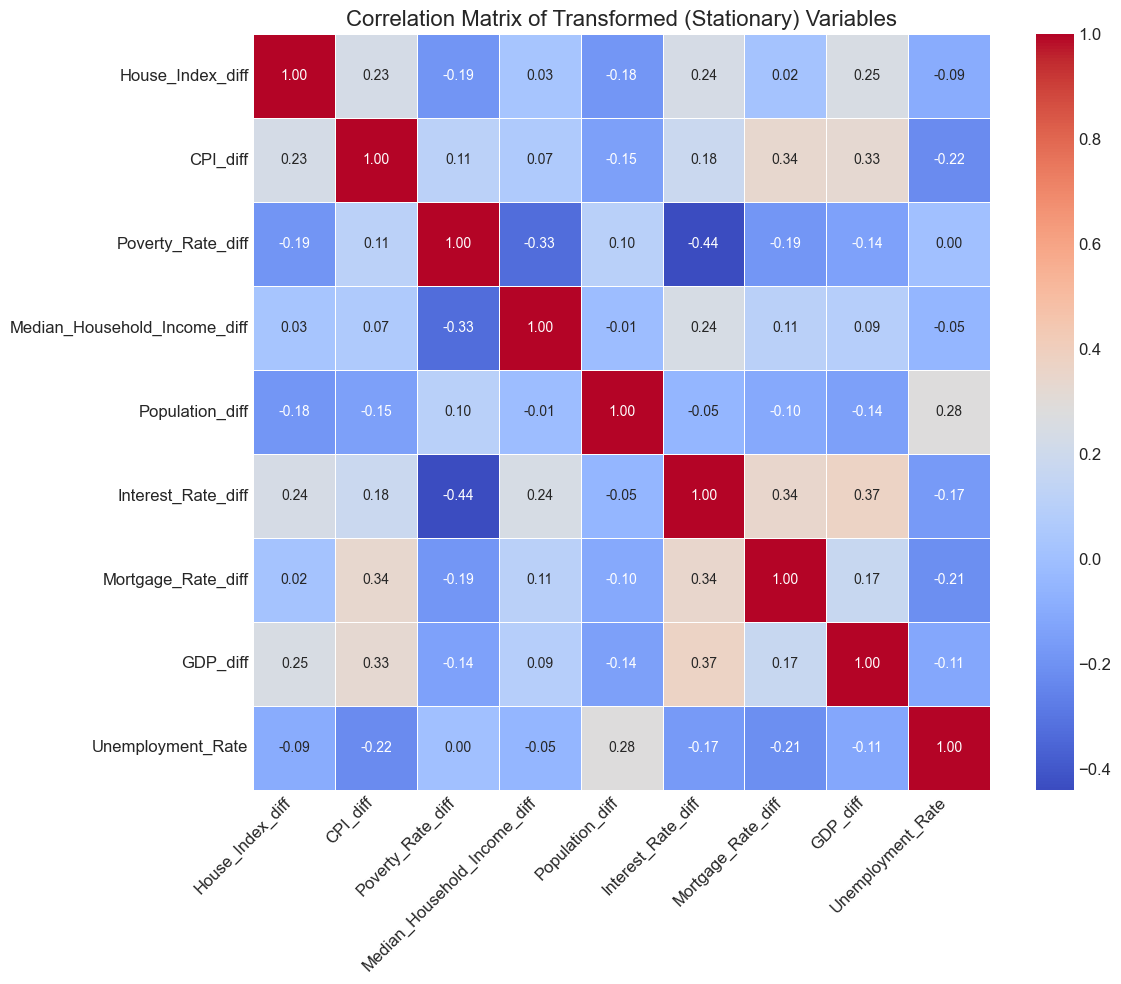


Correlation Matrix Values (Stationary Data):
                              House_Index_diff  CPI_diff  Poverty_Rate_diff  \
House_Index_diff                      1.000000  0.233643          -0.189305   
CPI_diff                              0.233643  1.000000           0.113078   
Poverty_Rate_diff                    -0.189305  0.113078           1.000000   
Median_Household_Income_diff          0.032271  0.065208          -0.330088   
Population_diff                      -0.180640 -0.145737           0.101142   
Interest_Rate_diff                    0.237965  0.184114          -0.438424   
Mortgage_Rate_diff                    0.021670  0.338674          -0.185090   
GDP_diff                              0.250505  0.326538          -0.136366   
Unemployment_Rate                    -0.094965 -0.224193           0.000795   

                              Median_Household_Income_diff  Population_diff  \
House_Index_diff                                  0.032271        -0.180640   
CPI_d

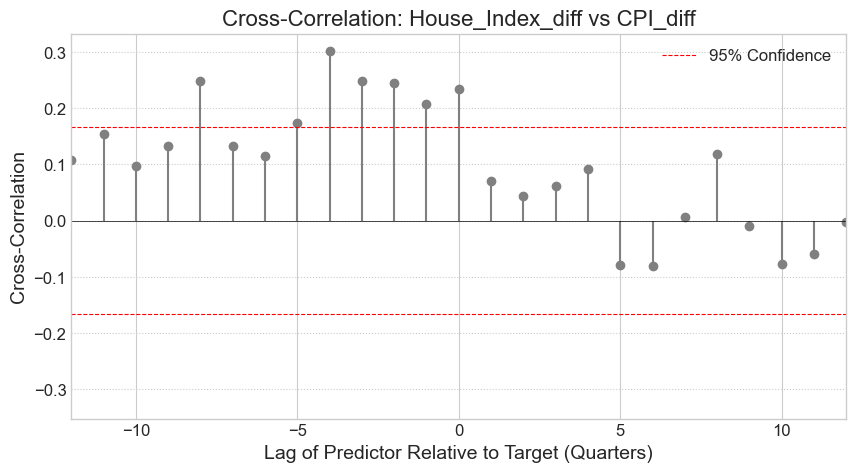


Cross-correlation: Poverty_Rate_diff vs House_Index_diff
  Max absolute correlation (predictor lags target): 0.172 at lag 1
  Max absolute correlation (predictor leads target): 0.046 at lag -1


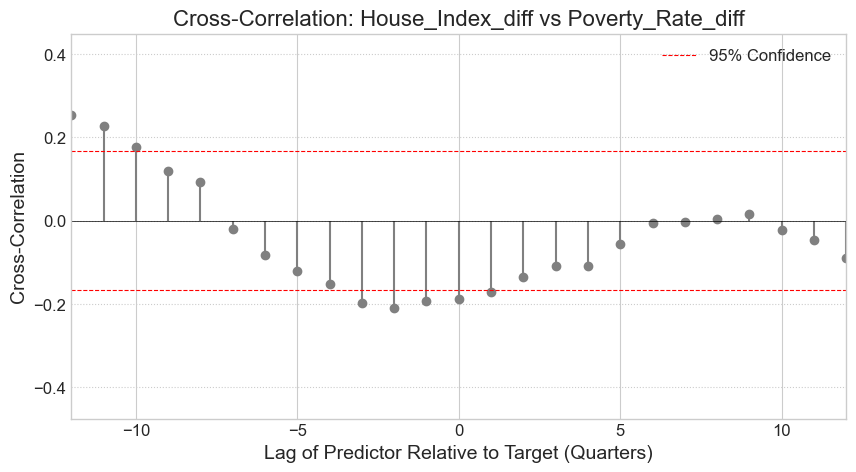


Cross-correlation: Median_Household_Income_diff vs House_Index_diff
  Max absolute correlation (predictor lags target): 0.111 at lag 5
  Max absolute correlation (predictor leads target): 0.035 at lag -1


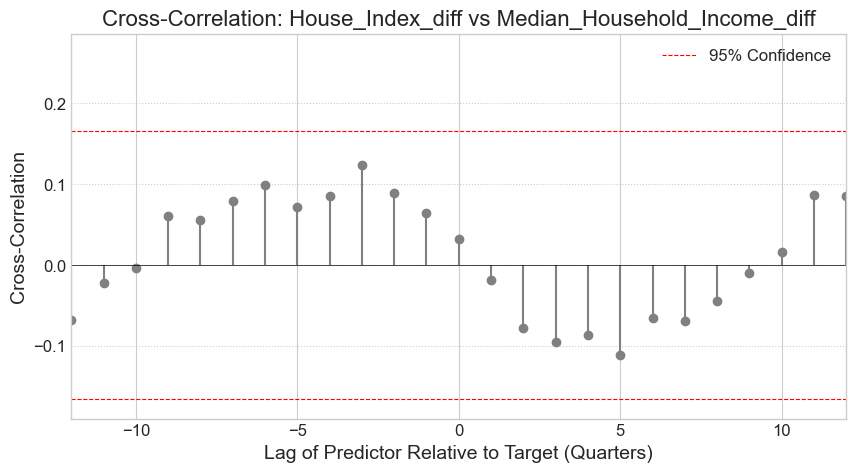


Cross-correlation: Population_diff vs House_Index_diff
  Max absolute correlation (predictor lags target): 0.214 at lag 3
  Max absolute correlation (predictor leads target): 0.003 at lag -1


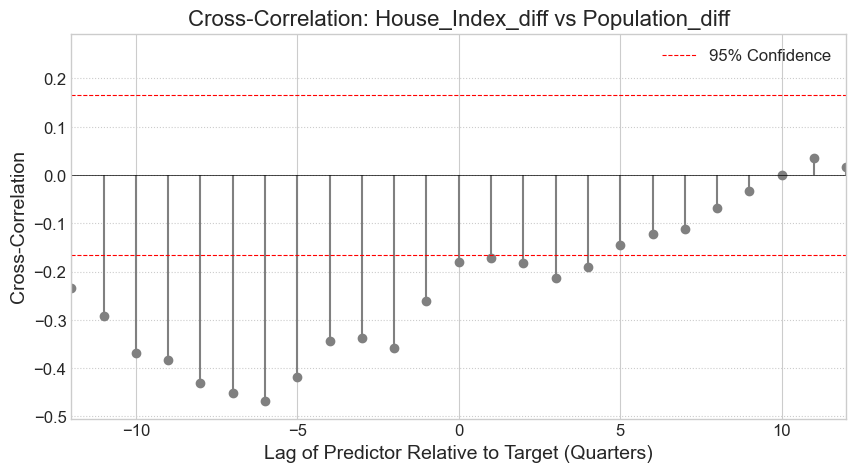


Cross-correlation: Interest_Rate_diff vs House_Index_diff
  Max absolute correlation (predictor lags target): 0.256 at lag 1
  Max absolute correlation (predictor leads target): 0.090 at lag -3


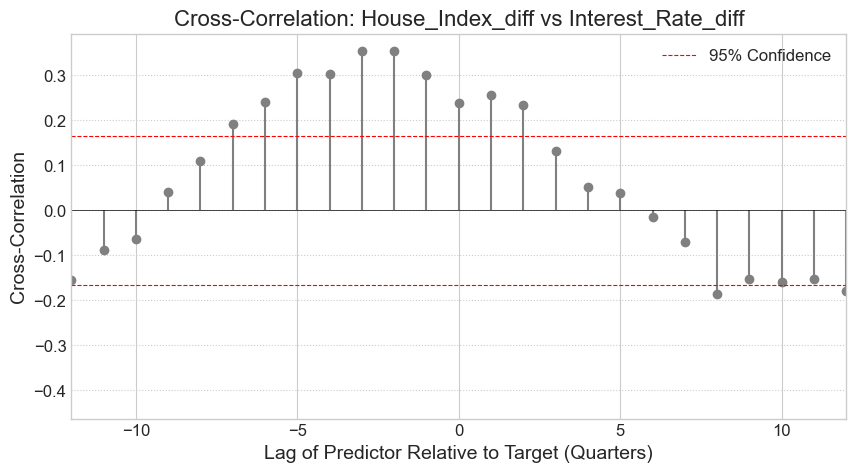


Cross-correlation: Mortgage_Rate_diff vs House_Index_diff
  Max absolute correlation (predictor lags target): 0.129 at lag 11
  Max absolute correlation (predictor leads target): 0.047 at lag -2


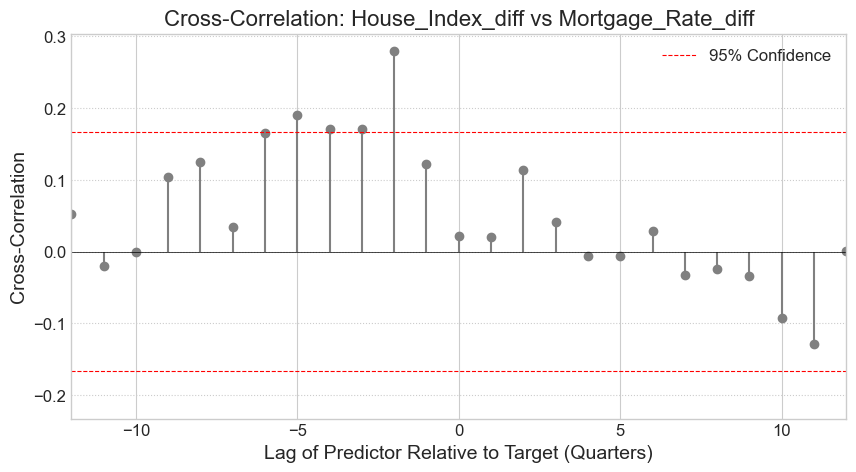


Cross-correlation: GDP_diff vs House_Index_diff
  Max absolute correlation (predictor lags target): 0.219 at lag 1
  Max absolute correlation (predictor leads target): 0.015 at lag -4


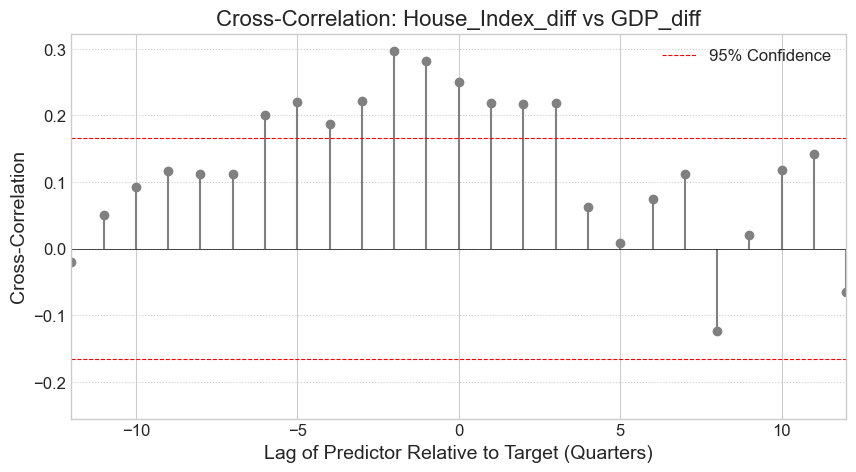


Cross-correlation: Unemployment_Rate vs House_Index_diff
  Max absolute correlation (predictor lags target): 0.086 at lag 9
  Max absolute correlation (predictor leads target): 0.029 at lag -6


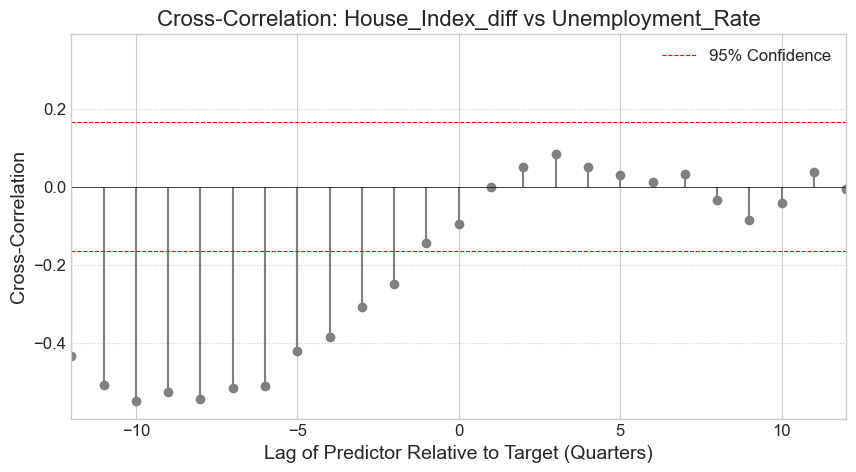


--- Granger Causality Tests (Predictor -> House_Index_diff) ---

Testing: CPI_diff -> House_Index_diff
  Result for max lag 4:
  'CPI_diff' does NOT significantly Granger-cause 'House_Index_diff' (p-value=0.0824)

Testing: Poverty_Rate_diff -> House_Index_diff
  Result for max lag 4:
  'Poverty_Rate_diff' does NOT significantly Granger-cause 'House_Index_diff' (p-value=0.9629)

Testing: Median_Household_Income_diff -> House_Index_diff
  Result for max lag 4:
  'Median_Household_Income_diff' does NOT significantly Granger-cause 'House_Index_diff' (p-value=0.5308)

Testing: Population_diff -> House_Index_diff
  Result for max lag 4:
  'Population_diff' does NOT significantly Granger-cause 'House_Index_diff' (p-value=0.2183)

Testing: Interest_Rate_diff -> House_Index_diff
  Result for max lag 4:
  'Interest_Rate_diff' does NOT significantly Granger-cause 'House_Index_diff' (p-value=0.4855)

Testing: Mortgage_Rate_diff -> House_Index_diff
  Result for max lag 4:
  'Mortgage_Rate_diff' do

In [12]:
# --- Step 6: Correlation and Causality Analysis (Stationary Data) ---
from statsmodels.tsa.stattools import ccf, grangercausalitytests
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Use the corrected transformed dataframe
df_stationary = df_transformed_corrected.copy()
target_variable_diff = 'House_Index_diff'
predictors_diff = [col for col in df_stationary.columns if col != target_variable_diff]

# 6.1 Correlation (Stationary Data)
print("\n--- Correlation Matrix (Stationary Data) ---")
correlation_matrix_stationary = df_stationary.corr()

# Plotting the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix_stationary, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, annot_kws={"size": 10}) # Adjust annot size if needed
plt.title('Correlation Matrix of Transformed (Stationary) Variables')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("\nCorrelation Matrix Values (Stationary Data):")
print(correlation_matrix_stationary)


# 6.2 Lead-Lag Analysis (Cross-Correlation)
print(f"\n--- Lead-Lag Analysis (Cross-Correlation with {target_variable_diff}) ---")
max_lags = 12 # Check lags up to 3 years (12 quarters)

# Ensure target and predictor are numpy arrays for ccf
target_series = df_stationary[target_variable_diff].values

for predictor in predictors_diff:
    print(f"\nCross-correlation: {predictor} vs {target_variable_diff}")
    predictor_series = df_stationary[predictor].values

    # Calculate cross-correlation function
    # Note: statsmodels ccf computes corr(y_t, x_{t-k}), so positive k means x lags y
    cross_corr = ccf(target_series, predictor_series, adjusted=False) # Use adjusted=False for raw correlation

    # Find the lag with the maximum absolute correlation
    max_abs_corr = np.max(np.abs(cross_corr[1:max_lags+1])) # Exclude lag 0 for lead/lag focus
    max_lag = np.argmax(np.abs(cross_corr[1:max_lags+1])) + 1 # Lag index starts from 1 here

    min_abs_corr = np.max(np.abs(cross_corr[-max_lags:])) # Check negative lags (predictor leads target)
    min_lag = -(np.argmax(np.abs(cross_corr[-max_lags:]))+1) if len(cross_corr[-max_lags:]) > 0 else 0


    print(f"  Max absolute correlation (predictor lags target): {max_abs_corr:.3f} at lag {max_lag}")
    print(f"  Max absolute correlation (predictor leads target): {min_abs_corr:.3f} at lag {min_lag}")

    # Plot CCF
    lags_positive = np.arange(len(cross_corr)) # Lags 0, 1, 2,...
    lags_negative = -np.arange(1, len(cross_corr))[::-1] # Lags ..., -2, -1
    lags_plot = np.concatenate((lags_negative, lags_positive))
    # Need to align cross_corr properly for plotting both negative and positive lags
    # The ccf output `cross_corr` corresponds to lags 0, 1, 2... (x lagging y)
    # For corr(y_t, x_{t+k}), we need ccf(x, y)
    cross_corr_yx = ccf(predictor_series, target_series, adjusted=False)
    ccf_plot = np.concatenate((cross_corr_yx[1:][::-1], cross_corr)) # Align: ..., ccf(y,x)_1, ccf(y,x)_0=ccf(x,y)_0, ccf(x,y)_1, ...


    plt.figure(figsize=(10, 5))
    plt.stem(lags_plot, ccf_plot, linefmt='grey', markerfmt='o', basefmt=" ")
    plt.xlim(-max_lags, max_lags)
    plt.xlabel('Lag of Predictor Relative to Target (Quarters)')
    plt.ylabel('Cross-Correlation')
    plt.title(f'Cross-Correlation: {target_variable_diff} vs {predictor}')
    plt.axhline(0, color='black', linewidth=0.5)
    # Add confidence bounds (approximate)
    conf_level = 1.96 / np.sqrt(len(target_series))
    plt.axhline(conf_level, color='red', linestyle='--', linewidth=0.8, label='95% Confidence')
    plt.axhline(-conf_level, color='red', linestyle='--', linewidth=0.8)
    plt.grid(True, axis='y', linestyle=':')
    plt.legend()
    plt.show()


# 6.3 Granger Causality Test
print(f"\n--- Granger Causality Tests (Predictor -> {target_variable_diff}) ---")
max_lag_gc = 4 # Test up to 4 lags (1 year)
gc_results = {}

for predictor in predictors_diff:
    print(f"\nTesting: {predictor} -> {target_variable_diff}")
    # Create a temporary DataFrame with only the target and one predictor for the test
    test_df = df_stationary[[target_variable_diff, predictor]].copy()

    try:
        # Perform the test
        # The test function prints results directly
        gc_test_result = grangercausalitytests(test_df[[target_variable_diff, predictor]], maxlag=max_lag_gc, verbose=False)

        # Store the p-value for the F-test at the chosen max lag
        # gc_test_result is a dict keyed by lag number. Each value is a dict of tests.
        # We typically look at the p-value for the 'ssr_ftest' at the max lag.
        p_value = gc_test_result[max_lag_gc][0]['ssr_ftest'][1]
        gc_results[predictor] = p_value

        print(f"  Result for max lag {max_lag_gc}:")
        if p_value < 0.05:
            print(f"  '{predictor}' significantly Granger-causes '{target_variable_diff}' (p-value={p_value:.4f})")
        else:
            print(f"  '{predictor}' does NOT significantly Granger-cause '{target_variable_diff}' (p-value={p_value:.4f})")

    except Exception as e:
        print(f"  Granger causality test failed for {predictor}: {e}")
        gc_results[predictor] = None

print("\nGranger Causality Summary (Predictor -> Target):")
print(gc_results)

In [13]:
# --- Step 7: Feature Engineering and Selection ---

# Start with the stationary data
df_features = df_transformed_corrected.copy()

# 7.1 Feature Creation

# --- Lag Features ---
# Create lags 1 to 4 for all predictors and the target variable itself
lag_cols = df_features.columns
num_lags = 4
for col in lag_cols:
    for i in range(1, num_lags + 1):
        df_features[f'{col}_lag{i}'] = df_features[col].shift(i)

print(f"Created lag features (1-{num_lags}) for {len(lag_cols)} variables.")


# --- Rolling Statistics Features ---
# Example: Rolling mean and std dev over 4 quarters for key variables
rolling_window = 4
vars_for_rolling = ['House_Index_diff', 'GDP_diff', 'Interest_Rate_diff', 'Unemployment_Rate']
for col in vars_for_rolling:
    if col in df_features.columns: # Check if the column exists (it should)
        df_features[f'{col}_roll_mean_{rolling_window}Q'] = df_features[col].rolling(window=rolling_window).mean()
        df_features[f'{col}_roll_std_{rolling_window}Q'] = df_features[col].rolling(window=rolling_window).std()
print(f"Created rolling mean/std features (window={rolling_window}Q) for {len(vars_for_rolling)} variables.")


# --- Context Variables ---

# Price-to-Income Ratio (using levels, then differencing)
# Need to use df_filled which has the original levels and the same start date as df_transformed_corrected index + 1 period
df_temp = df_filled[['House_Index', 'Median_Household_Income']].copy()
# Ensure income is not zero or negative before division
if (df_temp['Median_Household_Income'] <= 0).any():
    print("Warning: Non-positive Median_Household_Income found. Handling potential division by zero.")
    # Replace 0 or negative income with a small positive number or NaN before division
    df_temp['Median_Household_Income'] = df_temp['Median_Household_Income'].replace(0, np.nan)
    # Add more robust handling if needed
    df_temp.dropna(subset=['Median_Household_Income'], inplace=True)


df_temp['Price_Income_Ratio'] = df_temp['House_Index'] / df_temp['Median_Household_Income'] * 1000 # Multiply for better scale if needed

# Check stationarity of the ratio
print("\nChecking stationarity of Price_Income_Ratio (Level):")
# Need the helper functions from Step 3. Redefining minimally or assuming available.
# Assuming perform_adf_test and perform_kpss_test are available from previous execution context.
try:
    is_stationary_adf = perform_adf_test(df_temp['Price_Income_Ratio'].dropna(), 'Price_Income_Ratio')
    is_stationary_kpss = perform_kpss_test(df_temp['Price_Income_Ratio'].dropna(), 'Price_Income_Ratio', regression='c') # Test level stationarity

    if not is_stationary_adf or not is_stationary_kpss:
        print("Price_Income_Ratio is non-stationary. Calculating difference.")
        df_temp['Price_Income_Ratio_diff'] = df_temp['Price_Income_Ratio'].diff()
        # Align with df_features index
        df_features['Price_Income_Ratio_diff'] = df_temp['Price_Income_Ratio_diff'].loc[df_features.index]
        print("Added 'Price_Income_Ratio_diff' feature.")
        # Optional: Re-test stationarity of the differenced ratio
        # perform_adf_test(df_features['Price_Income_Ratio_diff'].dropna(), 'Price_Income_Ratio_diff')
        # perform_kpss_test(df_features['Price_Income_Ratio_diff'].dropna(), 'Price_Income_Ratio_diff', regression='c')
    else:
        print("Price_Income_Ratio is stationary. Adding level feature.")
        df_features['Price_Income_Ratio'] = df_temp['Price_Income_Ratio'].loc[df_features.index]

except NameError:
    print("Stationarity test functions not available. Assuming Price_Income_Ratio needs differencing.")
    df_temp['Price_Income_Ratio_diff'] = df_temp['Price_Income_Ratio'].diff()
    df_features['Price_Income_Ratio_diff'] = df_temp['Price_Income_Ratio_diff'].loc[df_features.index]
    print("Added 'Price_Income_Ratio_diff' feature (assumed non-stationary).")
except Exception as e:
    print(f"Error during Price_Income_Ratio processing: {e}")


# Recession Dummy
# Define recession periods again (ensure dates are correct)
recession_periods_dt = [(pd.to_datetime(start), pd.to_datetime(end), label) for start, end, label in recession_periods] # Using list from Step 2

# Create the dummy column, initialized to 0
df_features['Recession_Dummy'] = 0
for start, end, _ in recession_periods_dt:
    # Set dummy to 1 for dates within the recession period (inclusive start, exclusive end for quarterly alignment)
    # Ensure comparison works with the DataFrame index
    df_features.loc[(df_features.index >= start) & (df_features.index < end), 'Recession_Dummy'] = 1
print("Added 'Recession_Dummy' feature.")


# 7.2 Final Cleanup
print(f"\nShape before dropping NaNs from features: {df_features.shape}")

# Drop rows with NaN values resulting from lags and rolling windows
df_final_features = df_features.dropna()

print(f"Shape after dropping NaNs: {df_final_features.shape}")
print(f"Usable data range: {df_final_features.index.min()} to {df_final_features.index.max()}")

# Identify final target and predictors
final_target = 'House_Index_diff'
final_predictors = [col for col in df_final_features.columns if col != final_target]

print(f"\nFinal Target Variable: {final_target}")
print(f"Final Predictor Variables ({len(final_predictors)}):")
# print(final_predictors) # Keep commented out for brevity unless needed

# Display first few rows of the final feature set
print("\nFirst 5 rows of df_final_features:")
print(df_final_features.head())

# Display last few rows of the final feature set
print("\nLast 5 rows of df_final_features:")
print(df_final_features.tail())

Created lag features (1-4) for 9 variables.
Created rolling mean/std features (window=4Q) for 4 variables.

Checking stationarity of Price_Income_Ratio (Level):

--- ADF Test for Price_Income_Ratio ---
ADF Statistic: -1.3361
p-value: 0.6125
Critical Values:
   1%: -3.4817
   5%: -2.8840
   10%: -2.5788
Result: Fail to reject the null hypothesis (H0). 'Price_Income_Ratio' is likely non-stationary.

--- KPSS Test for Price_Income_Ratio (regression='c') ---
KPSS Statistic: 1.1668
p-value: 0.0100
Number of Lags Used: 6
Critical Values:
   10%: 0.3470
   5%: 0.4630
   2.5%: 0.5740
   1%: 0.7390
Result: Reject the null hypothesis (H0). 'Price_Income_Ratio' is likely non-stationary.
Price_Income_Ratio is non-stationary. Calculating difference.
Added 'Price_Income_Ratio_diff' feature.
Added 'Recession_Dummy' feature.

Shape before dropping NaNs from features: (139, 55)
Shape after dropping NaNs: (135, 55)
Usable data range: 1991-04-01 00:00:00 to 2024-10-01 00:00:00

Final Target Variable: Hou